# IF3270 Pembelajaran Mesin — Tugas Besar 1
## FFNN From Scratch: Global Student Placement & Salary


## 1. Import Required Libraries

In [26]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from utils import (
    run_architecture_experiments,
    run_learning_rate_experiments,
    plot_train_val_curves,
    plot_prediction_bars,
    analyze_results_distributions,
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)

## 2. Load and Explore the Dataset

In [27]:
DATA_PATH = '../data/student_placement_salary.csv'

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [28]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.describe()

cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

Missing values:
 cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64


,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [29]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)


college_tier:
college_tier
Tier 2    3993
Tier 1    3034
Tier 3    2973
Name: count, dtype: int64
----------------------------------------

country:
country
Germany    2057
USA        2040
India      1985
Canada     1976
UK         1942
Name: count, dtype: int64
----------------------------------------

university_ranking_band:
university_ranking_band
300+       4075
100-300    3975
Top 100    1950
Name: count, dtype: int64
----------------------------------------

specialization:
specialization
Data Science     2036
Core CS          2007
Cybersecurity    1992
AI/ML            1991
Cloud            1974
Name: count, dtype: int64
----------------------------------------

industry:
industry
Consulting       1739
Healthcare       1680
Manufacturing    1673
Tech             1643
Finance          1635
Other            1630
Name: count, dtype: int64
----------------------------------------

placement_status:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
--

## 3. Data Preprocessing

In [30]:
TARGET_COL  = 'placement_status'   

df = df.dropna(subset=[TARGET_COL])

# 2. Encode categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]

label_cols = ['college_tier', 'university_ranking_band']
ohe_cols = [o for o in cat_cols if o not in label_cols]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

# 3. Encode target
y_raw = le.fit_transform(df[TARGET_COL].astype(str))
n_classes = len(np.unique(y_raw))

if n_classes == 2:
    # Binary classification → sigmoid + BCE
    y = y_raw.reshape(-1, 1).astype(float)
    TASK = 'binary'
else:
    # Multi-class → softmax + CCE (one-hot)
    y = np.eye(n_classes)[y_raw]
    TASK = 'multiclass'

print(f"Task: {TASK}, classes: {n_classes}, y shape: {y.shape}")

# 4. Feature matrix
X_df = df.drop(columns=[TARGET_COL])
X_df = X_df.select_dtypes(include=[np.number]).fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values).astype(float)
print(f"X shape: {X.shape}")

# 5. Train / validation / test split  (60 / 20 / 20)
X_tmp,  X_test,  y_tmp,  y_test  = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Task: binary, classes: 2, y shape: (10000, 1)
X shape: (10000, 8)
Train: (6000, 8), Val: (2000, 8), Test: (2000, 8)


## 4. Model Testing


### 4.1 Hyperparameter

#### 4.1.1 Depth and Width Parameter

In [31]:
n_features = X_train.shape[1]
n_out      = y_train.shape[1]

experiments = {
    # Width Variations (depth = 2 tetap)
    'Width_Small': [
        {'n_in': n_features,  'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': 16, 'activation': 'relu'},
        {'n_in': 16, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Medium': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Large': [
        {'n_in': n_features,   'n_out': 128, 'activation': 'relu'},
        {'n_in': 128, 'n_out': 64,  'activation': 'relu'},
        {'n_in': 64,  'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    
    # Depth Variations (width = 64 tetap)
    'Depth_1': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_2': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_3': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
}


In [32]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

results = run_architecture_experiments(
    experiments=experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Width_Small
  Layer 1: DenseLayer(8 → 32, activation=ReLU)  [288 params]
  Layer 2: DenseLayer(32 → 16, activation=ReLU)  [528 params]
  Layer 3: DenseLayer(16 → 1, activation=Sigmoid)  [17 params]
----------------------------------------------------
  Total params: 833
Epoch 10/200, Train Loss: 0.5416, Val Loss: 0.5312
Epoch 20/200, Train Loss: 0.5070, Val Loss: 0.5032
Epoch 30/200, Train Loss: 0.5012, Val Loss: 0.4985
Epoch 40/200, Train Loss: 0.4960, Val Loss: 0.4956
Epoch 50/200, Train Loss: 0.4936, Val Loss: 0.4938
Epoch 60/200, Train Loss: 0.4923, Val Loss: 0.4941
Epoch 70/200, Train Loss: 0.4922, Val Loss: 0.4949
Epoch 80/200, Train Loss: 0.4910, Val Loss: 0.4964
Epoch 90/200, Train Loss: 0.4914, Val Loss: 0.4959
Epoch 100/200, Train Loss: 0.4901, Val Loss: 0.4974
Epoch 110/200, Train Loss: 0.4895, Val Loss: 0.4978
Epoch 120/200, Train Loss: 0.4890, Val Loss: 0.4980
Epoch 130/200, Train Loss: 0.4898, Val Loss: 0.4986
Epoch 140/200, Train Loss: 0.4883, Val Loss: 0.5009


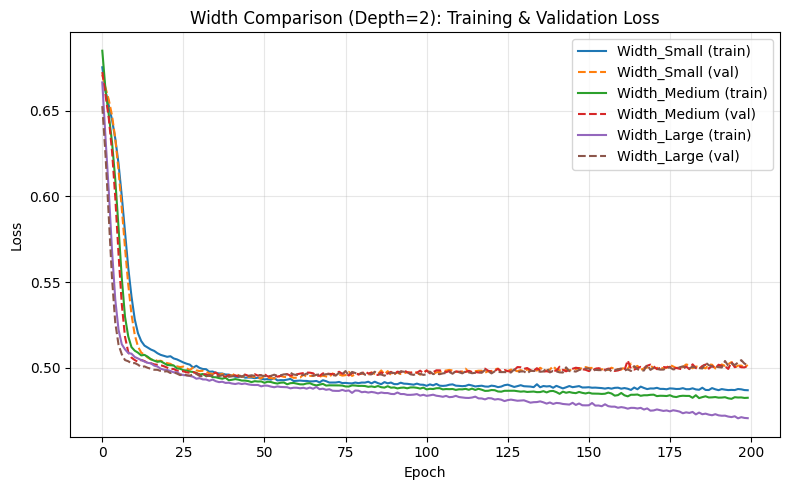

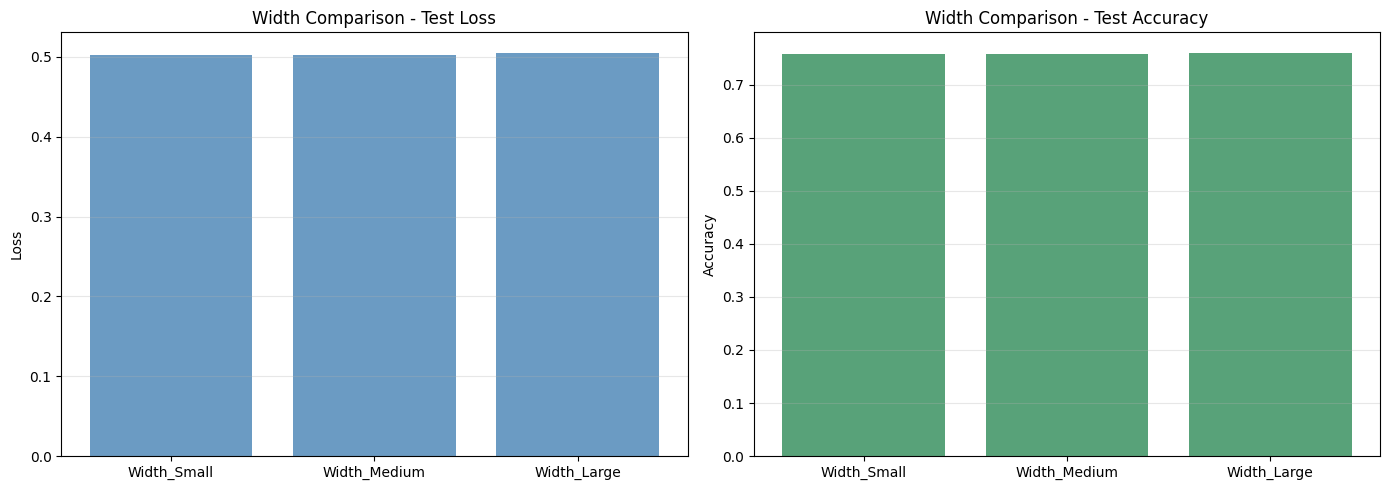

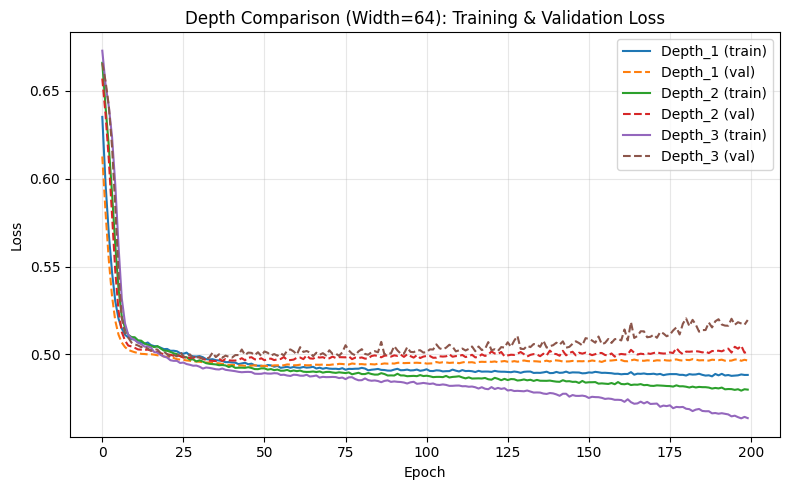

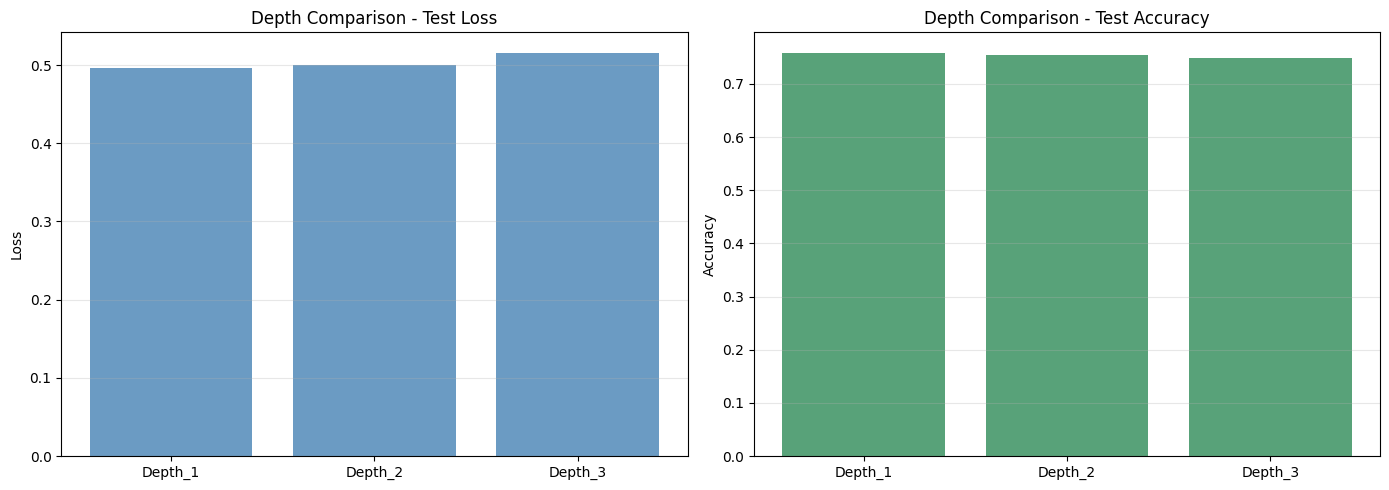

In [33]:
width_results = {k: results[k] for k in ['Width_Small', 'Width_Medium', 'Width_Large']}
depth_results = {k: results[k] for k in ['Depth_1', 'Depth_2', 'Depth_3']}

plot_train_val_curves(
    width_results,
    title='Width Comparison (Depth=2): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    width_results,
    title_prefix='Width Comparison',
)

plot_train_val_curves(
    depth_results,
    title='Depth Comparison (Width=64): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    depth_results,
    title_prefix='Depth Comparison',
)

### 4.1.2 Fungsi Aktivasi

In [34]:
BASE_ARCH = [128, 64]

activation_functions = ['linear', 'relu', 'leaky_relu', 'elu', 'sigmoid', 'tanh']

activation_experiments = {}

for act_name in activation_functions:
    config = []
    
    # Hidden Layer 1
    config.append({
        'n_in': n_features,
        'n_out': BASE_ARCH[0],
        'activation': act_name
    })
    
    # Hidden Layer 2
    config.append({
        'n_in': BASE_ARCH[0],
        'n_out': BASE_ARCH[1],
        'activation': 'relu'
    })
    
    # Output Layer
    config.append({
        'n_in': BASE_ARCH[1],
        'n_out': n_out,
        'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'
    })
    
    exp_suffix = act_name.replace('_', ' ').title().replace(' ', '_')
    activation_experiments[f'Act_{exp_suffix}'] = config

print('Activation Function Experiments:')
for name, config in activation_experiments.items():
    tested_act = config[0]['activation']
    fixed_act = config[1]['activation']
    print(f"  {name}: L1='{tested_act}', L2 fixed='{fixed_act}'")

Activation Function Experiments:
  Act_Linear: L1='linear', L2 fixed='relu'
  Act_Relu: L1='relu', L2 fixed='relu'
  Act_Leaky_Relu: L1='leaky_relu', L2 fixed='relu'
  Act_Elu: L1='elu', L2 fixed='relu'
  Act_Sigmoid: L1='sigmoid', L2 fixed='relu'
  Act_Tanh: L1='tanh', L2 fixed='relu'


In [35]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

activation_results = run_architecture_experiments(
    experiments=activation_experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Act_Linear
  Layer 1: DenseLayer(8 → 128, activation=Linear)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5049, Val Loss: 0.4994
Epoch 20/200, Train Loss: 0.4967, Val Loss: 0.4937
Epoch 30/200, Train Loss: 0.4931, Val Loss: 0.4935
Epoch 40/200, Train Loss: 0.4923, Val Loss: 0.4932
Epoch 50/200, Train Loss: 0.4917, Val Loss: 0.4930
Epoch 60/200, Train Loss: 0.4904, Val Loss: 0.4942
Epoch 70/200, Train Loss: 0.4904, Val Loss: 0.4942
Epoch 80/200, Train Loss: 0.4894, Val Loss: 0.4942
Epoch 90/200, Train Loss: 0.4894, Val Loss: 0.4948
Epoch 100/200, Train Loss: 0.4892, Val Loss: 0.4956
Epoch 110/200, Train Loss: 0.4892, Val Loss: 0.4948
Epoch 120/200, Train Loss: 0.4882, Val Loss: 0.4961
Epoch 130/200, Train Loss: 0.4876, Val Loss: 0.4945
Epoch 140/200, Train Loss: 0.4883, Val Loss

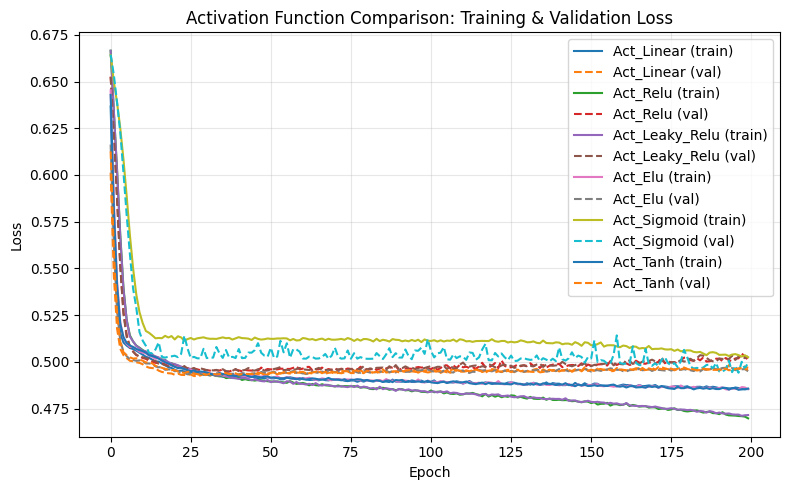

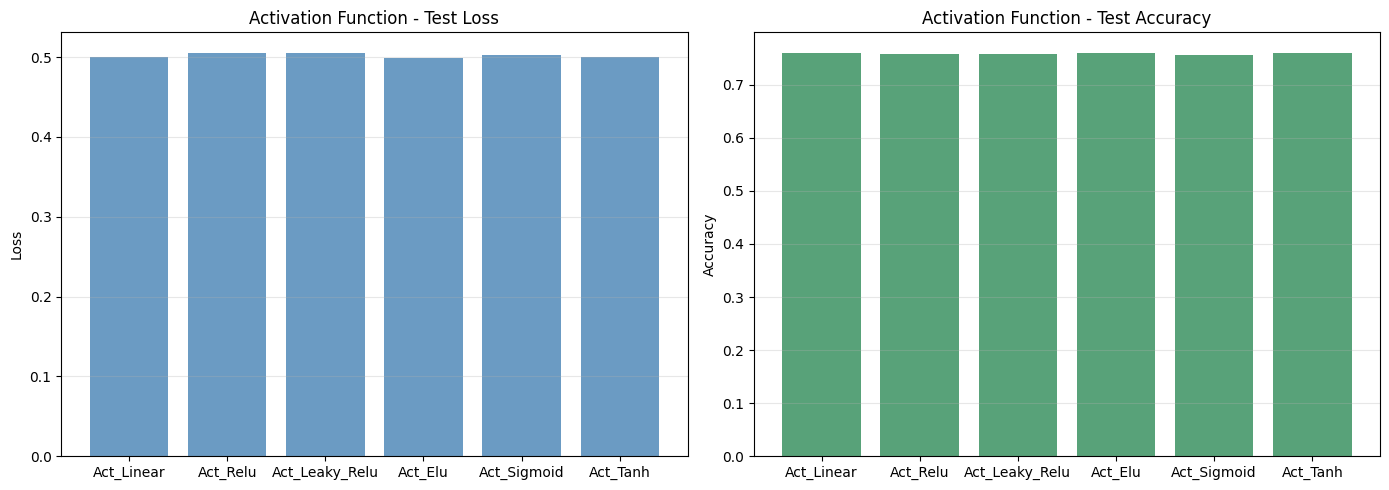

In [36]:
plot_train_val_curves(
    activation_results,
    title='Activation Function Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    activation_results,
    title_prefix='Activation Function',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Linear
Test Accuracy: 0.7595

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.004777 | Std: 0.112725
  Min: -0.412282 | Max: 0.389357
  Median: -0.002115

Layer 1:
  Shape: (128, 64)
  Mean: -0.000688 | Std: 0.102250
  Min: -0.443770 | Max: 0.409412
  Median: -0.001099

Layer 2:
  Shape: (64, 1)
  Mean: 0.040819 | Std: 0.230975
  Min: -0.461680 | Max: 0.631530
  Median: 0.058913

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000496 | Std: 0.008787
  Min: -0.059969 | Max: 0.043258
  Median: 0.000755
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

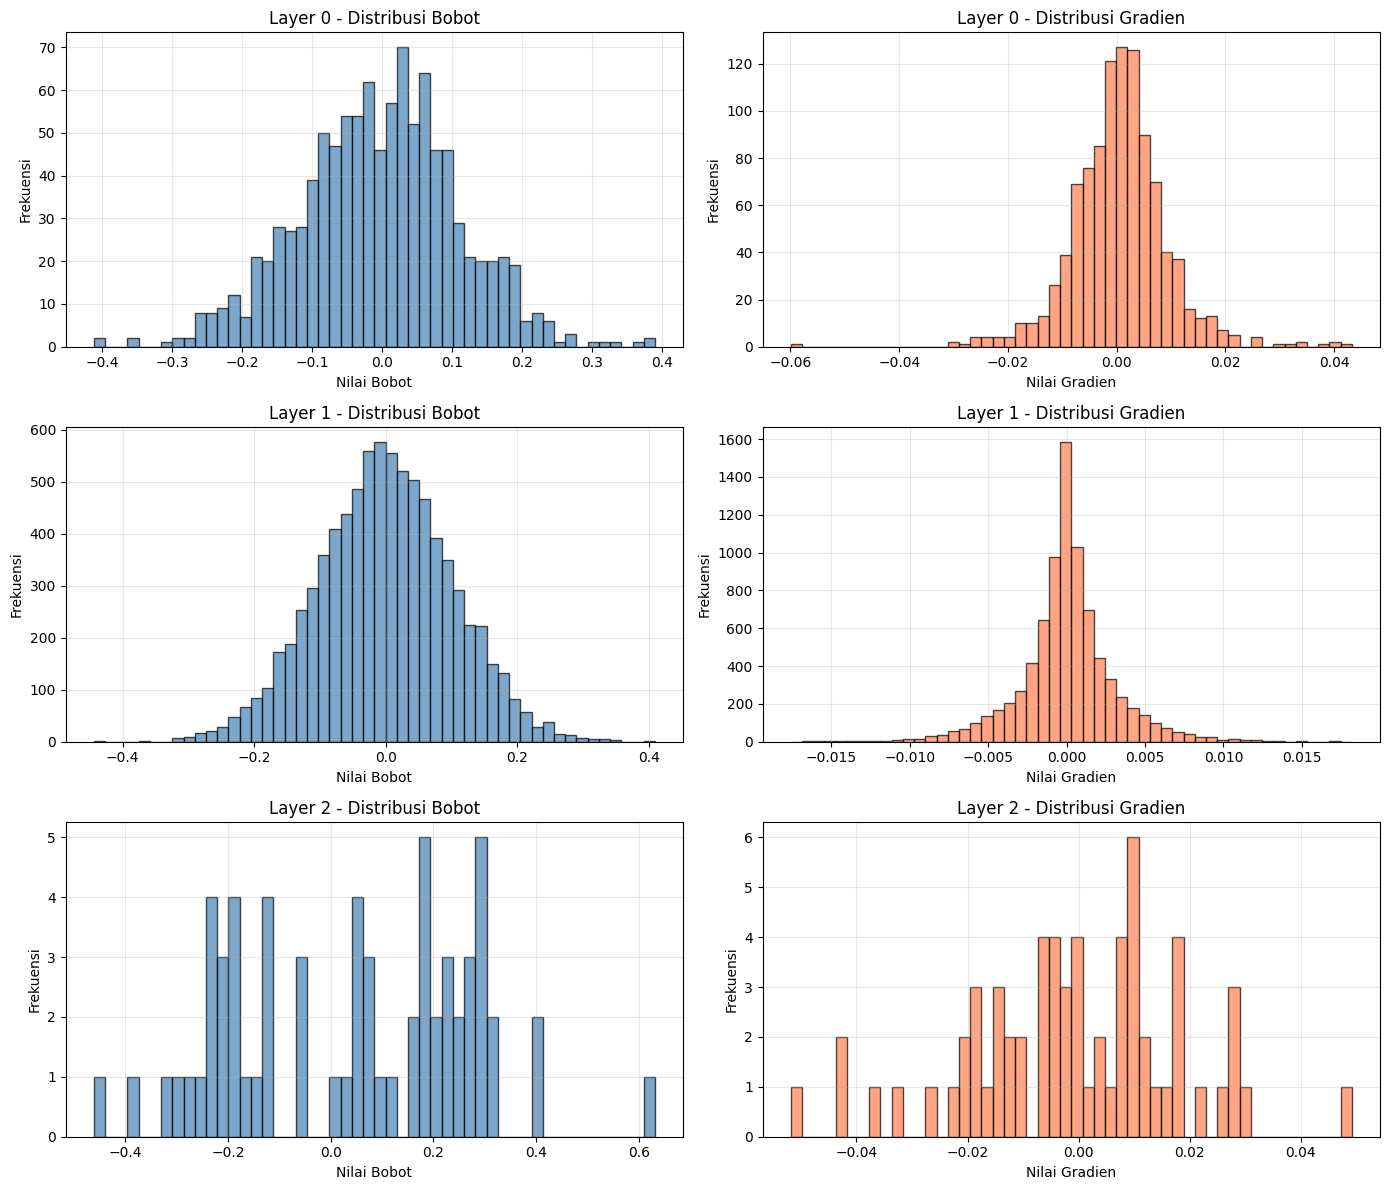


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Relu
Test Accuracy: 0.7580

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001787 | Std: 0.125181
  Min: -0.394294 | Max: 0.546620
  Median: 0.001250

Layer 1:
  Shape: (128, 64)
  Mean: 0.001632 | Std: 0.103925
  Min: -0.439533 | Max: 0.415756
  Median: 0.001967

Layer 2:
  Shape: (64, 1)
  Mean: 0.031533 | Std: 0.308960
  Min: -0.626278 | Max: 0.703250
  Median: 0.030225

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000901 | Std: 0.015868
  Min: -0.079686 | Max: 0.083523
  Median: -0.000430
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128,

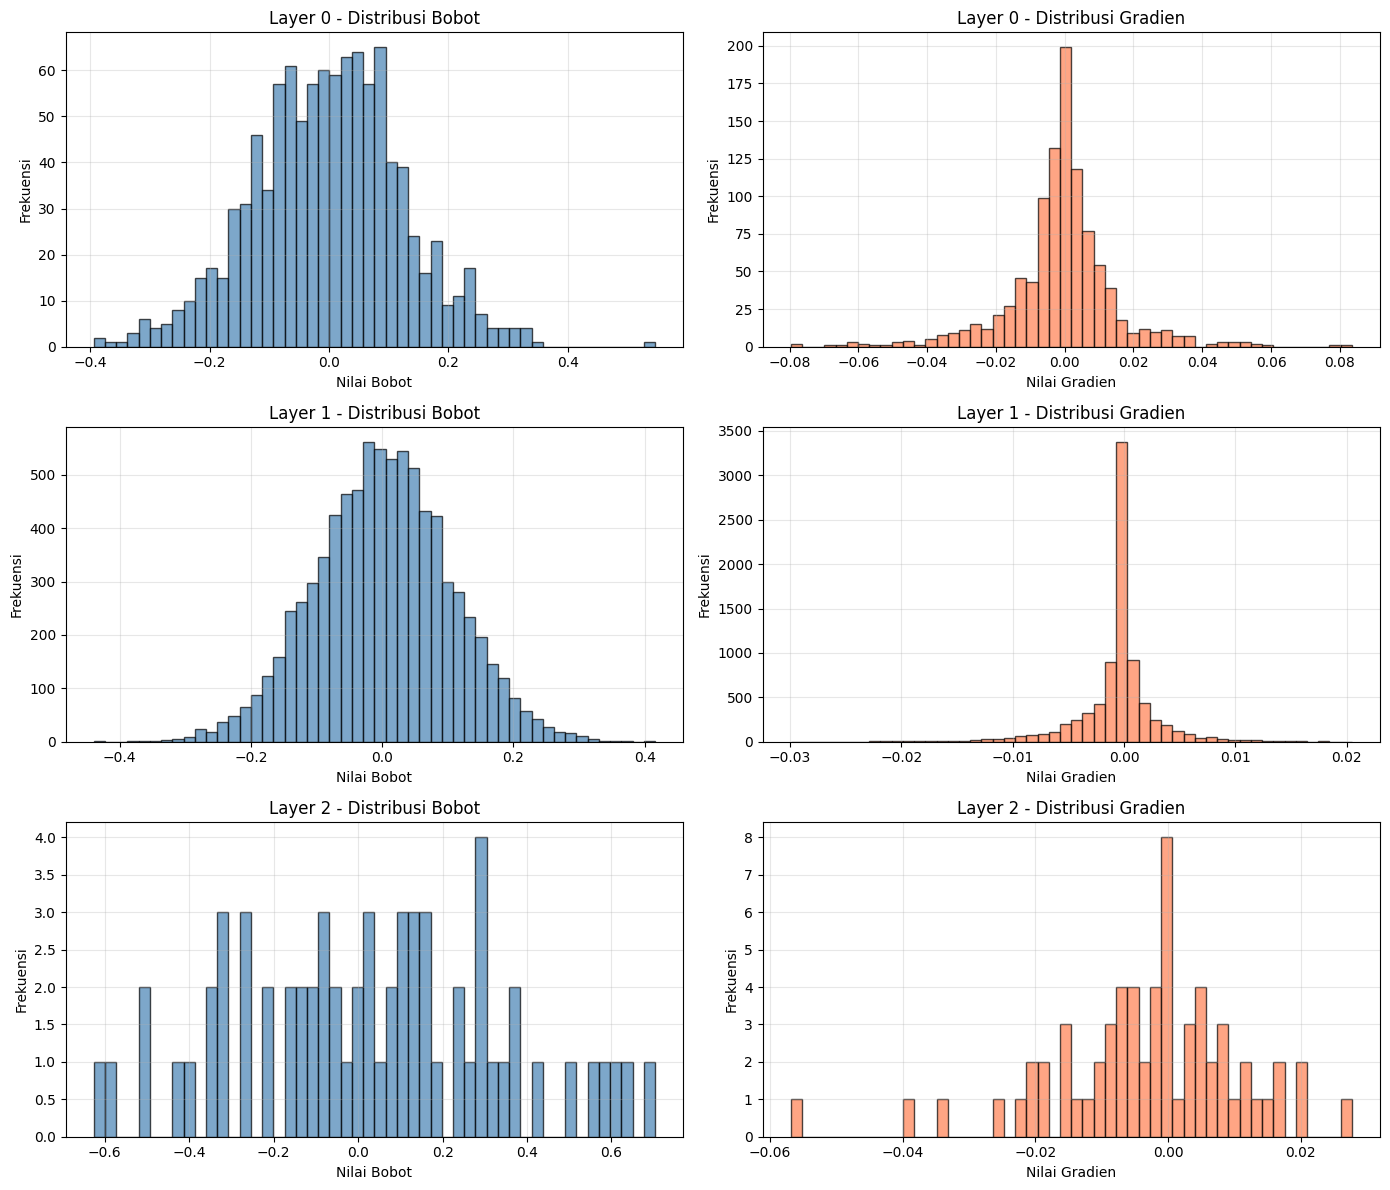


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Leaky_Relu
Test Accuracy: 0.7580

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001800 | Std: 0.124925
  Min: -0.403231 | Max: 0.545787
  Median: 0.001798

Layer 1:
  Shape: (128, 64)
  Mean: 0.001542 | Std: 0.103906
  Min: -0.438297 | Max: 0.419285
  Median: 0.001797

Layer 2:
  Shape: (64, 1)
  Mean: 0.033446 | Std: 0.308064
  Min: -0.608613 | Max: 0.702462
  Median: 0.034372

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.001152 | Std: 0.022853
  Min: -0.078893 | Max: 0.112917
  Median: 0.000409
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (

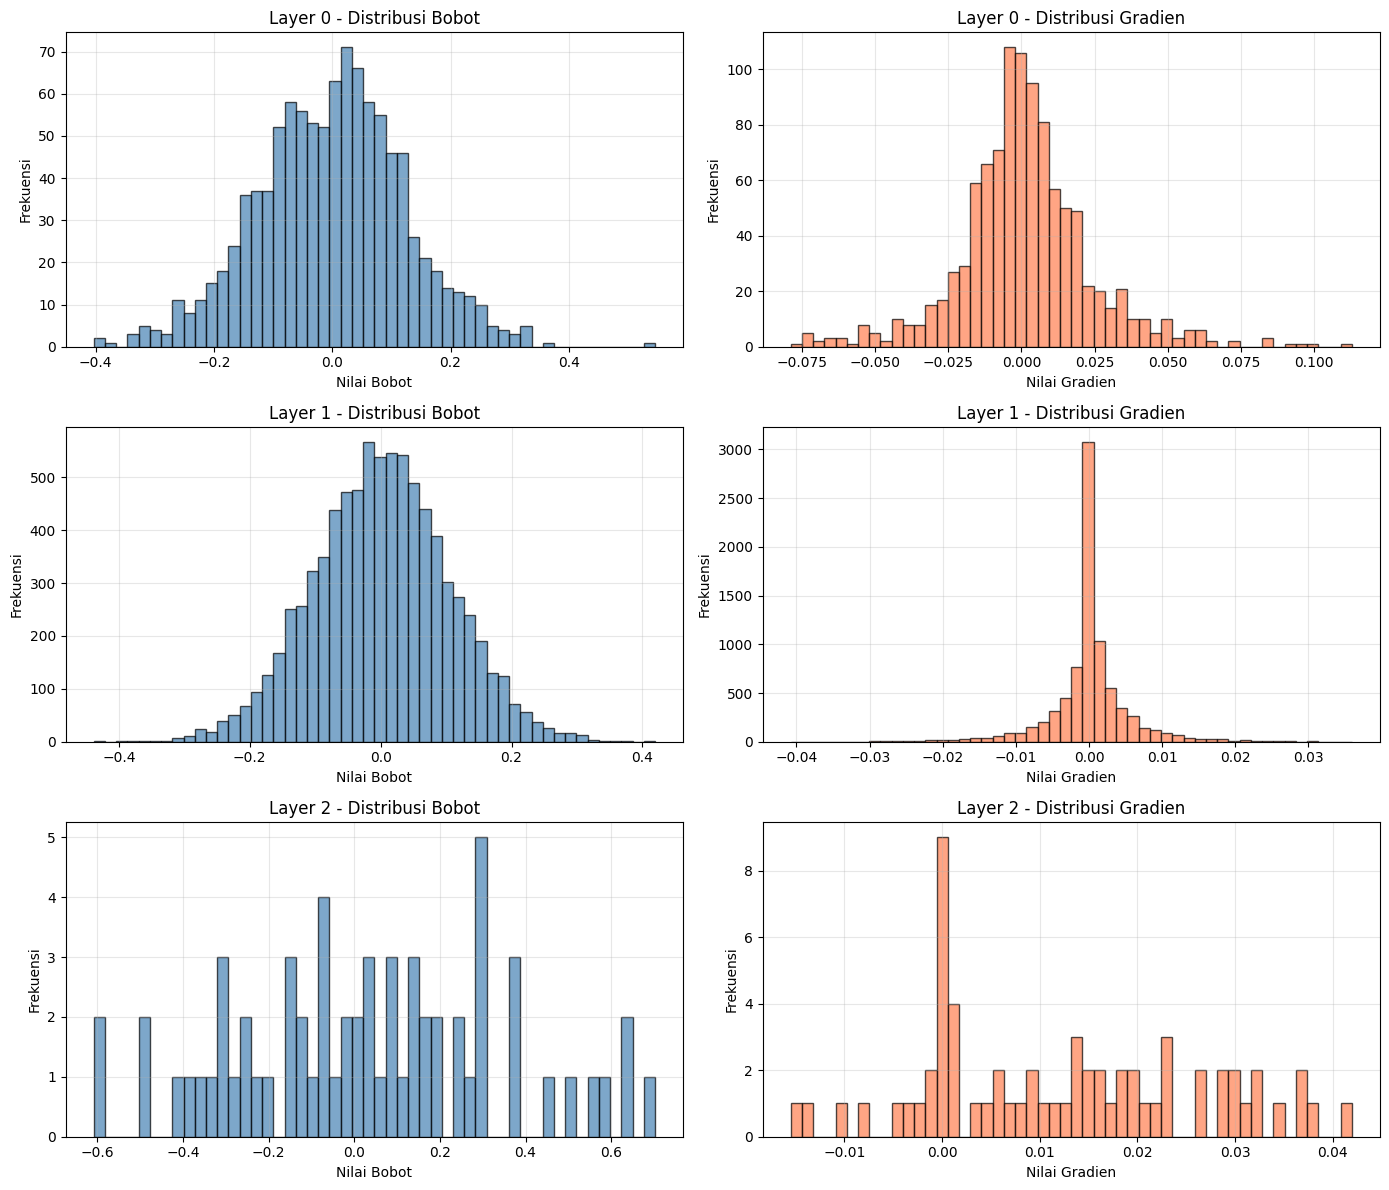


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Elu
Test Accuracy: 0.7610

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.004805 | Std: 0.113444
  Min: -0.409256 | Max: 0.414491
  Median: -0.000477

Layer 1:
  Shape: (128, 64)
  Mean: -0.000322 | Std: 0.102371
  Min: -0.450557 | Max: 0.402341
  Median: -0.000534

Layer 2:
  Shape: (64, 1)
  Mean: 0.045810 | Std: 0.236803
  Min: -0.429046 | Max: 0.635637
  Median: 0.056240

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000703 | Std: 0.021481
  Min: -0.120821 | Max: 0.130062
  Median: 0.001294
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128,

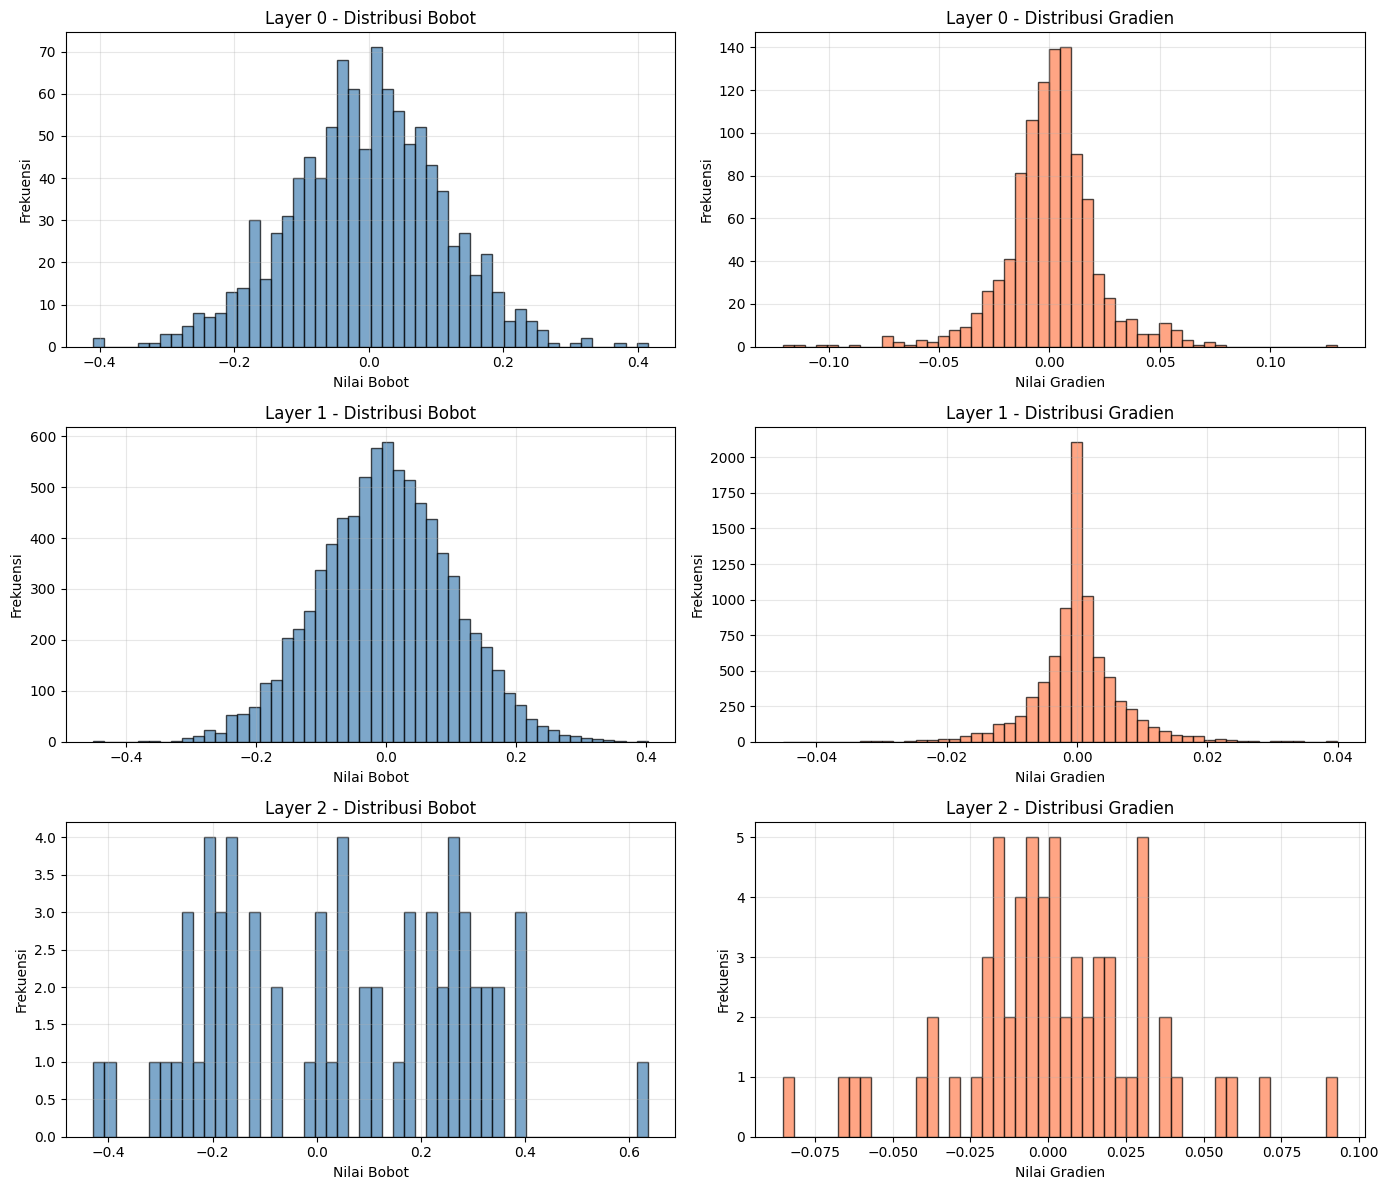


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Sigmoid
Test Accuracy: 0.7570

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002138 | Std: 0.116098
  Min: -0.382050 | Max: 0.407085
  Median: 0.002482

Layer 1:
  Shape: (128, 64)
  Mean: 0.000178 | Std: 0.102778
  Min: -0.438911 | Max: 0.437524
  Median: 0.000440

Layer 2:
  Shape: (64, 1)
  Mean: 0.027368 | Std: 0.223392
  Min: -0.412406 | Max: 1.018921
  Median: 0.012226

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000092 | Std: 0.004878
  Min: -0.025108 | Max: 0.023782
  Median: 0.000052
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

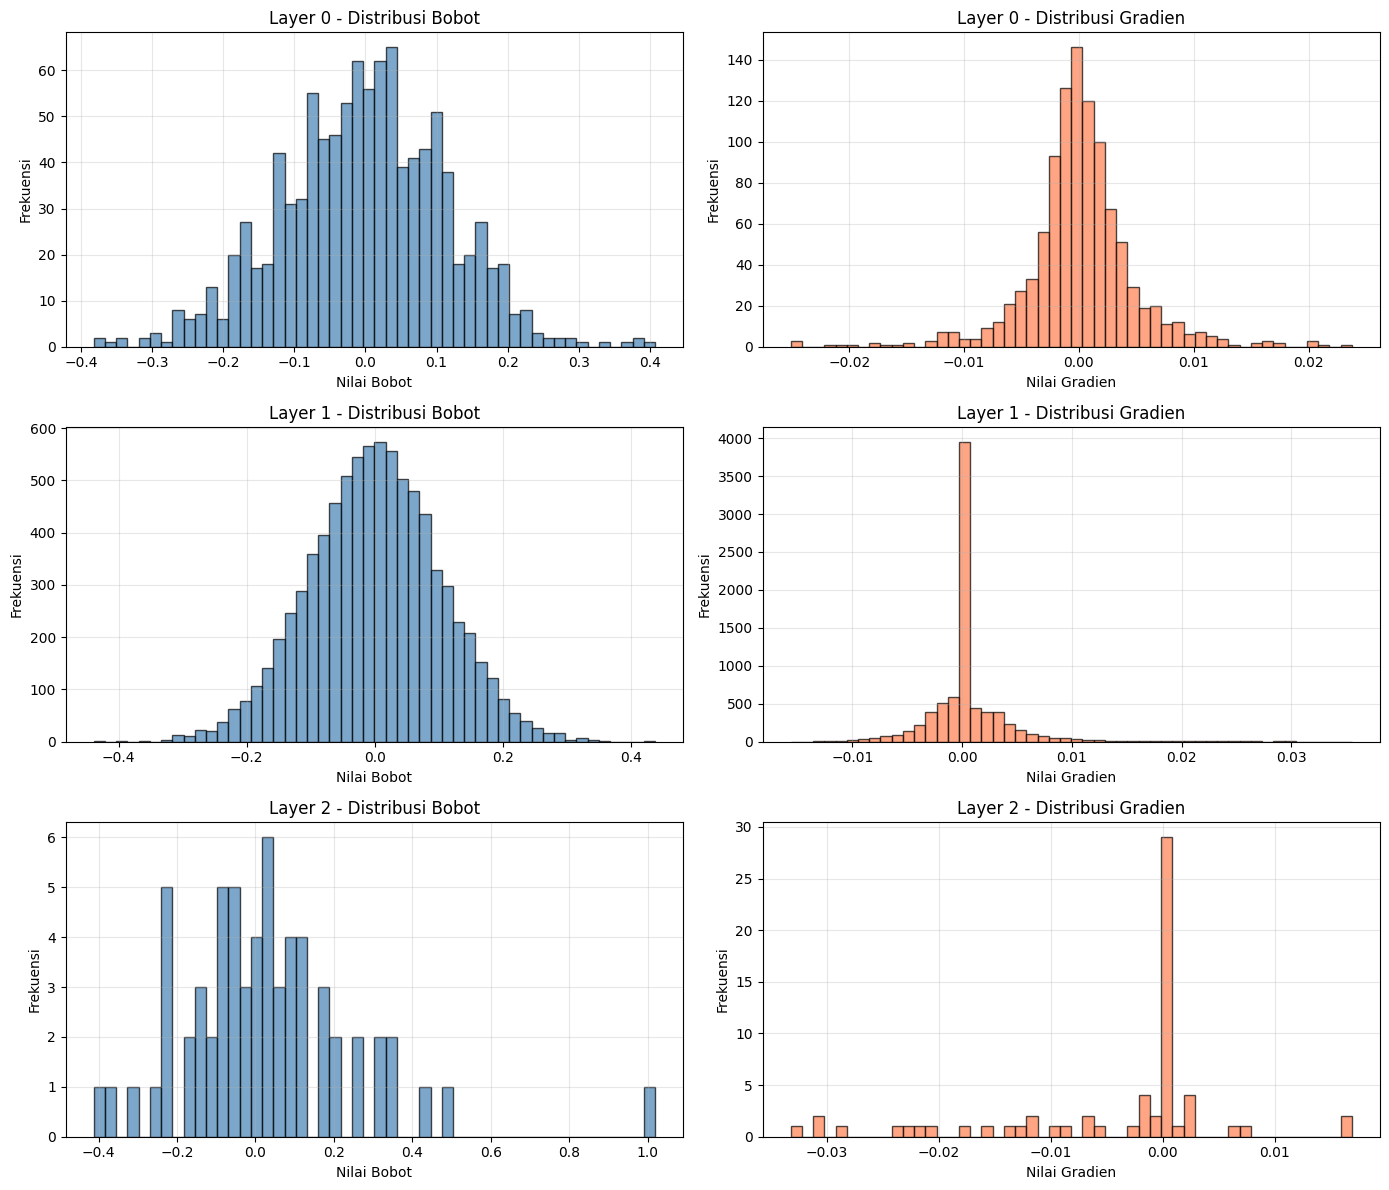


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Tanh
Test Accuracy: 0.7600

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.004534 | Std: 0.113284
  Min: -0.400327 | Max: 0.411956
  Median: -0.001520

Layer 1:
  Shape: (128, 64)
  Mean: -0.000854 | Std: 0.102379
  Min: -0.453527 | Max: 0.398710
  Median: -0.000891

Layer 2:
  Shape: (64, 1)
  Mean: 0.043619 | Std: 0.238630
  Min: -0.460692 | Max: 0.648455
  Median: 0.061451

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000057 | Std: 0.014068
  Min: -0.056144 | Max: 0.061884
  Median: 0.000090
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

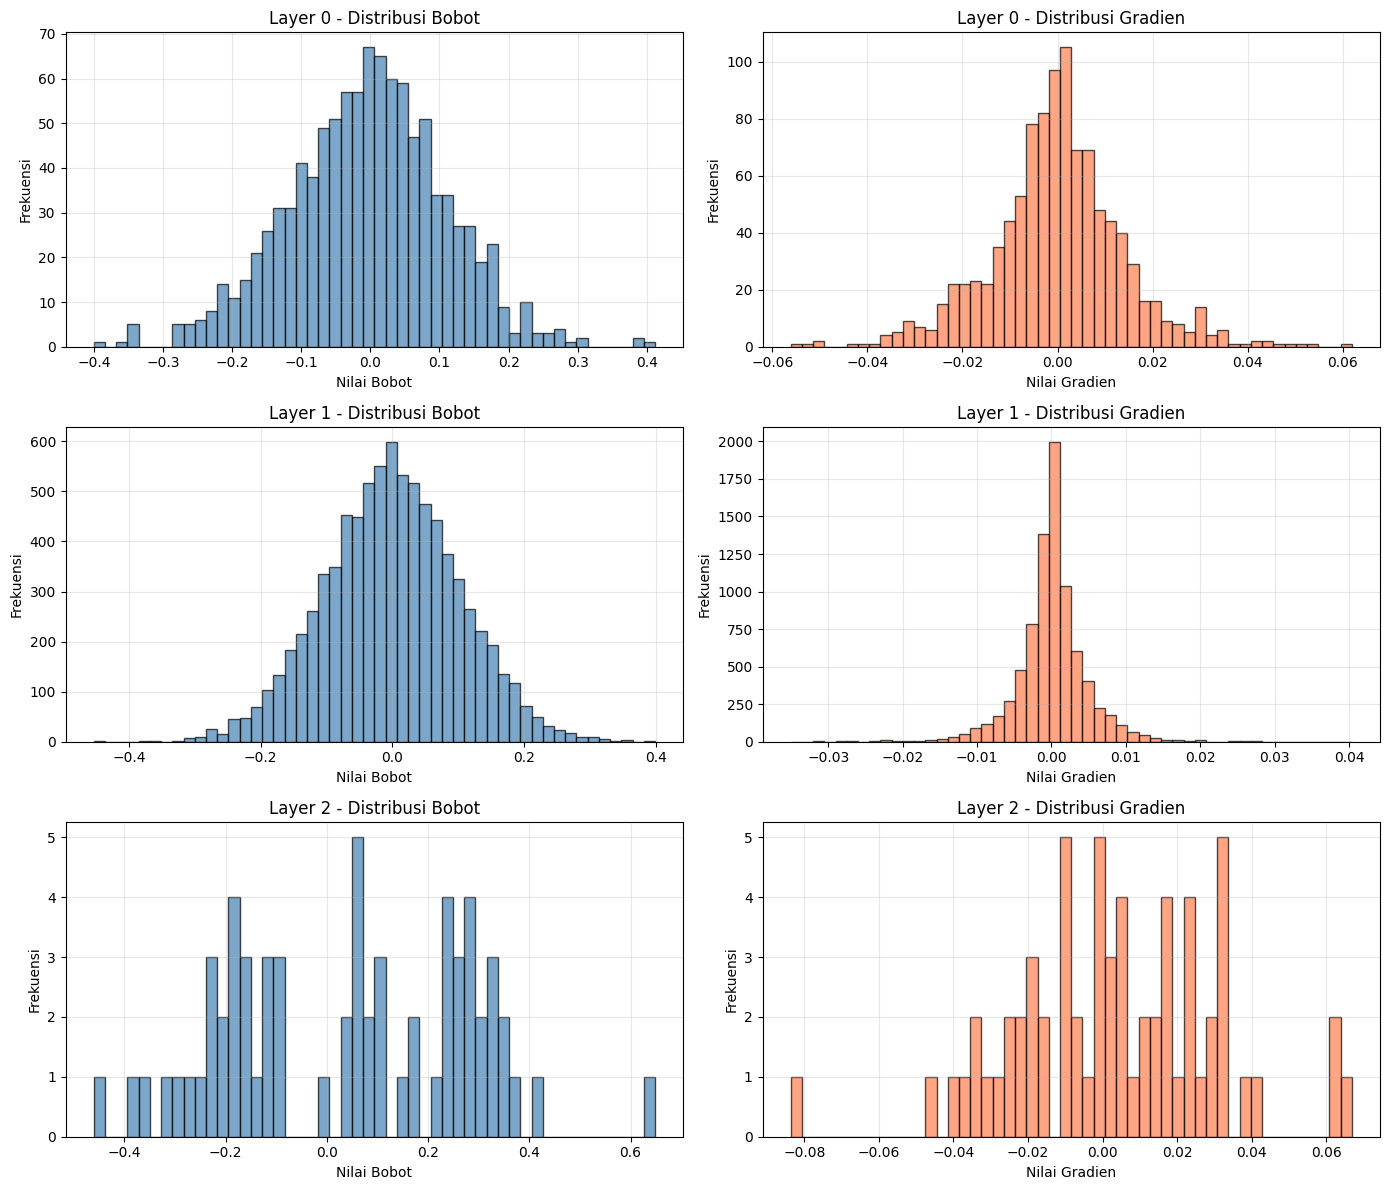

In [37]:
analyze_results_distributions(
    activation_results,
    result_group_name='Activation',
)

### 4.1.3 Learning Rate

In [38]:
learning_rates = {
    'LR_0.001': 0.001,
    'LR_0.01': 0.01,
    'LR_0.1': 0.1,
}

BASE_LR_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

lr_results = run_learning_rate_experiments(
    learning_rates=learning_rates,
    base_arch=BASE_LR_ARCH,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: LR_0.001 (lr=0.001)
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5079, Val Loss: 0.5025
Epoch 20/200, Train Loss: 0.4992, Val Loss: 0.4977
Epoch 30/200, Train Loss: 0.4939, Val Loss: 0.4954
Epoch 40/200, Train Loss: 0.4910, Val Loss: 0.4961
Epoch 50/200, Train Loss: 0.4892, Val Loss: 0.4960
Epoch 60/200, Train Loss: 0.4882, Val Loss: 0.4964
Epoch 70/200, Train Loss: 0.4875, Val Loss: 0.4956
Epoch 80/200, Train Loss: 0.4860, Val Loss: 0.4960
Epoch 90/200, Train Loss: 0.4853, Val Loss: 0.4959
Epoch 100/200, Train Loss: 0.4841, Val Loss: 0.4964
Epoch 110/200, Train Loss: 0.4830, Val Loss: 0.4964
Epoch 120/200, Train Loss: 0.4819, Val Loss: 0.4967
Epoch 130/200, Train Loss: 0.4806, Val Loss: 0.4988
Epoch 140/200, Train Loss: 0.4787, V

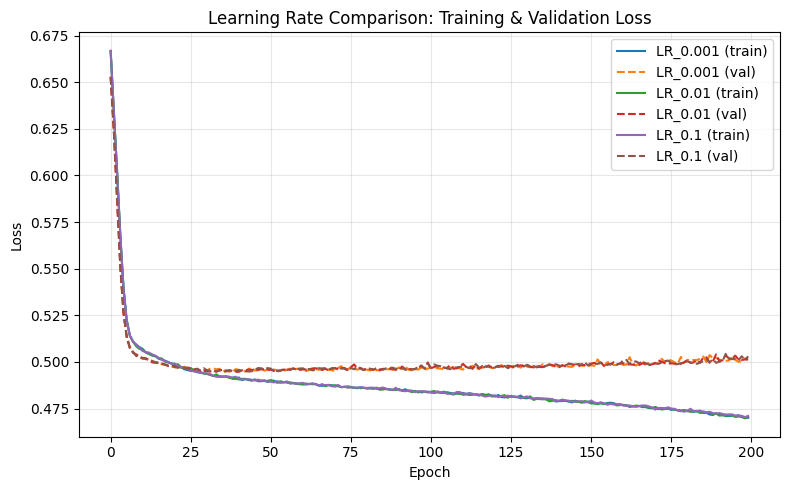

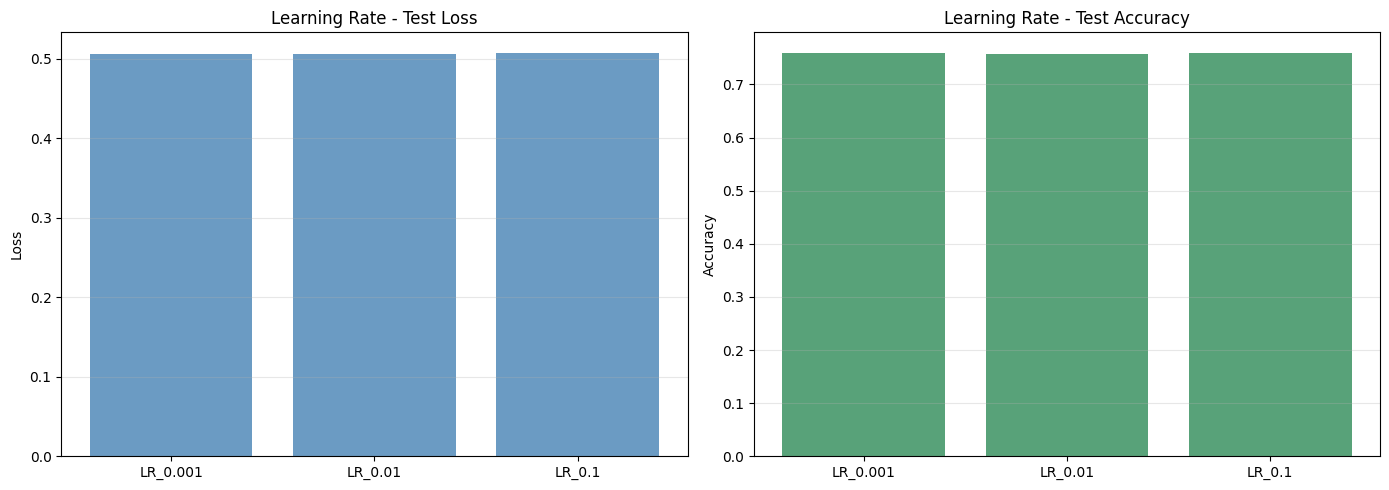

In [39]:
plot_train_val_curves(
    lr_results,
    title='Learning Rate Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    lr_results,
    title_prefix='Learning Rate',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.001
Test Accuracy: 0.7595

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001726 | Std: 0.125197
  Min: -0.393910 | Max: 0.551801
  Median: 0.001378

Layer 1:
  Shape: (128, 64)
  Mean: 0.001617 | Std: 0.103936
  Min: -0.438887 | Max: 0.418680
  Median: 0.001744

Layer 2:
  Shape: (64, 1)
  Mean: 0.032035 | Std: 0.309318
  Min: -0.626877 | Max: 0.691931
  Median: 0.034230

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000206 | Std: 0.027860
  Min: -0.164289 | Max: 0.139000
  Median: -0.000162
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

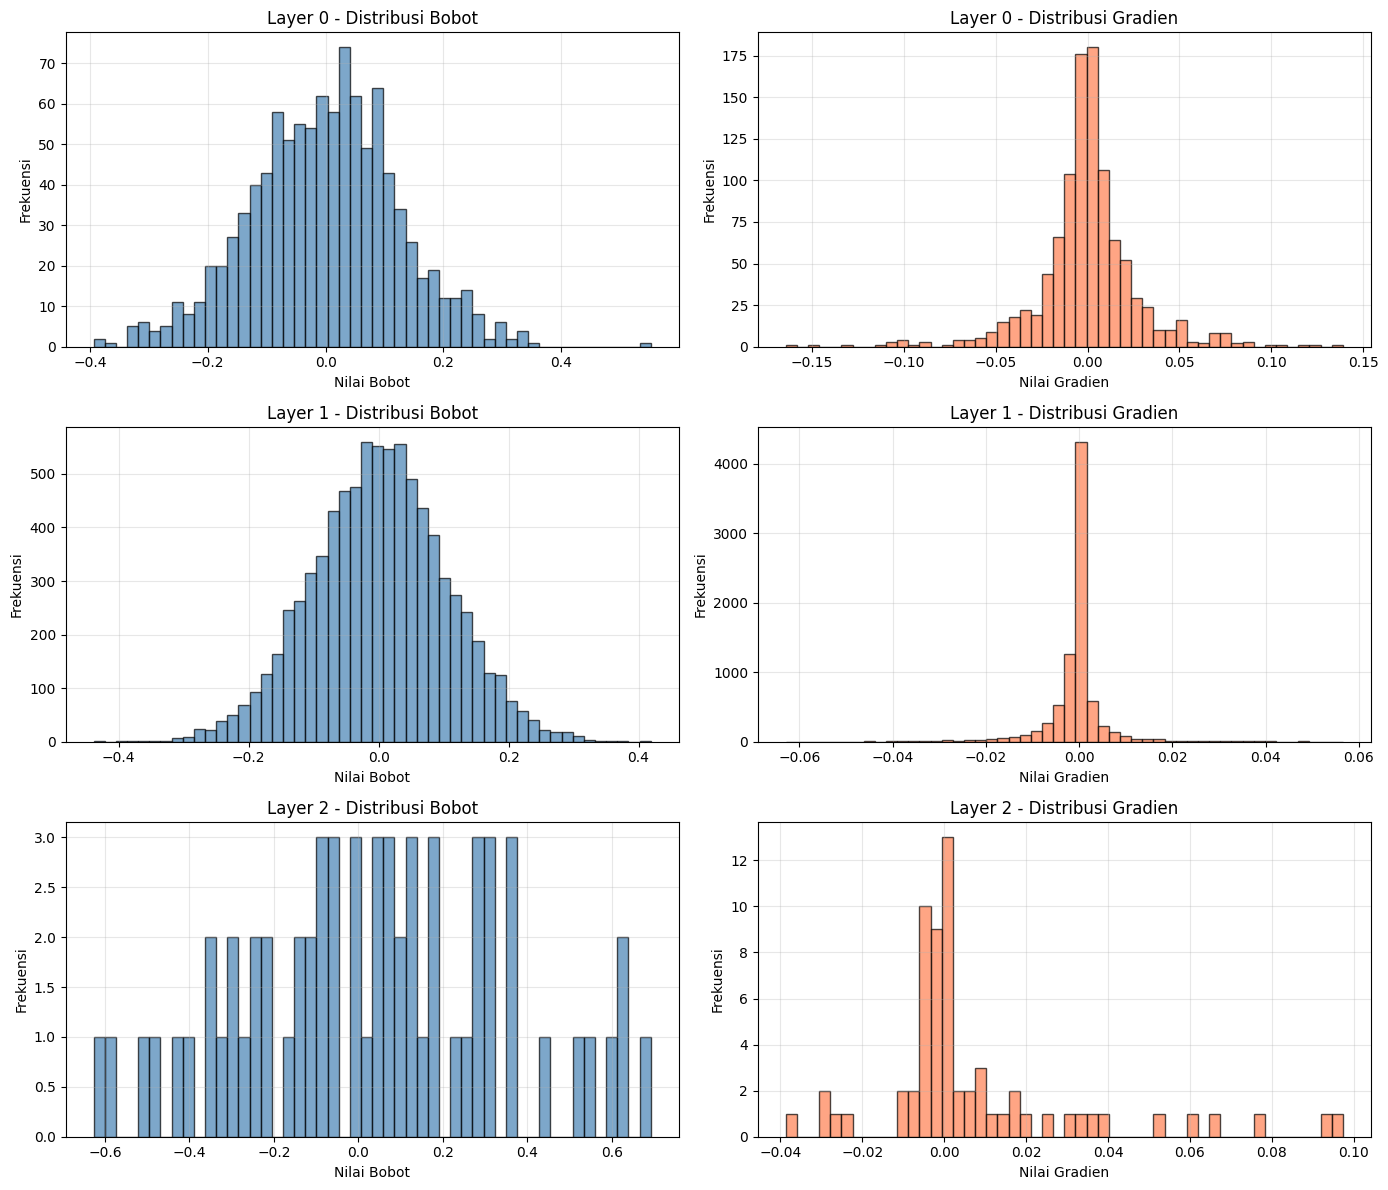


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.01
Test Accuracy: 0.7565

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001831 | Std: 0.125366
  Min: -0.400538 | Max: 0.548659
  Median: 0.002045

Layer 1:
  Shape: (128, 64)
  Mean: 0.001594 | Std: 0.103951
  Min: -0.439331 | Max: 0.410690
  Median: 0.001810

Layer 2:
  Shape: (64, 1)
  Mean: 0.032397 | Std: 0.309734
  Min: -0.624366 | Max: 0.709549
  Median: 0.032454

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000115 | Std: 0.020187
  Min: -0.106454 | Max: 0.106509
  Median: 0.000128
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128,

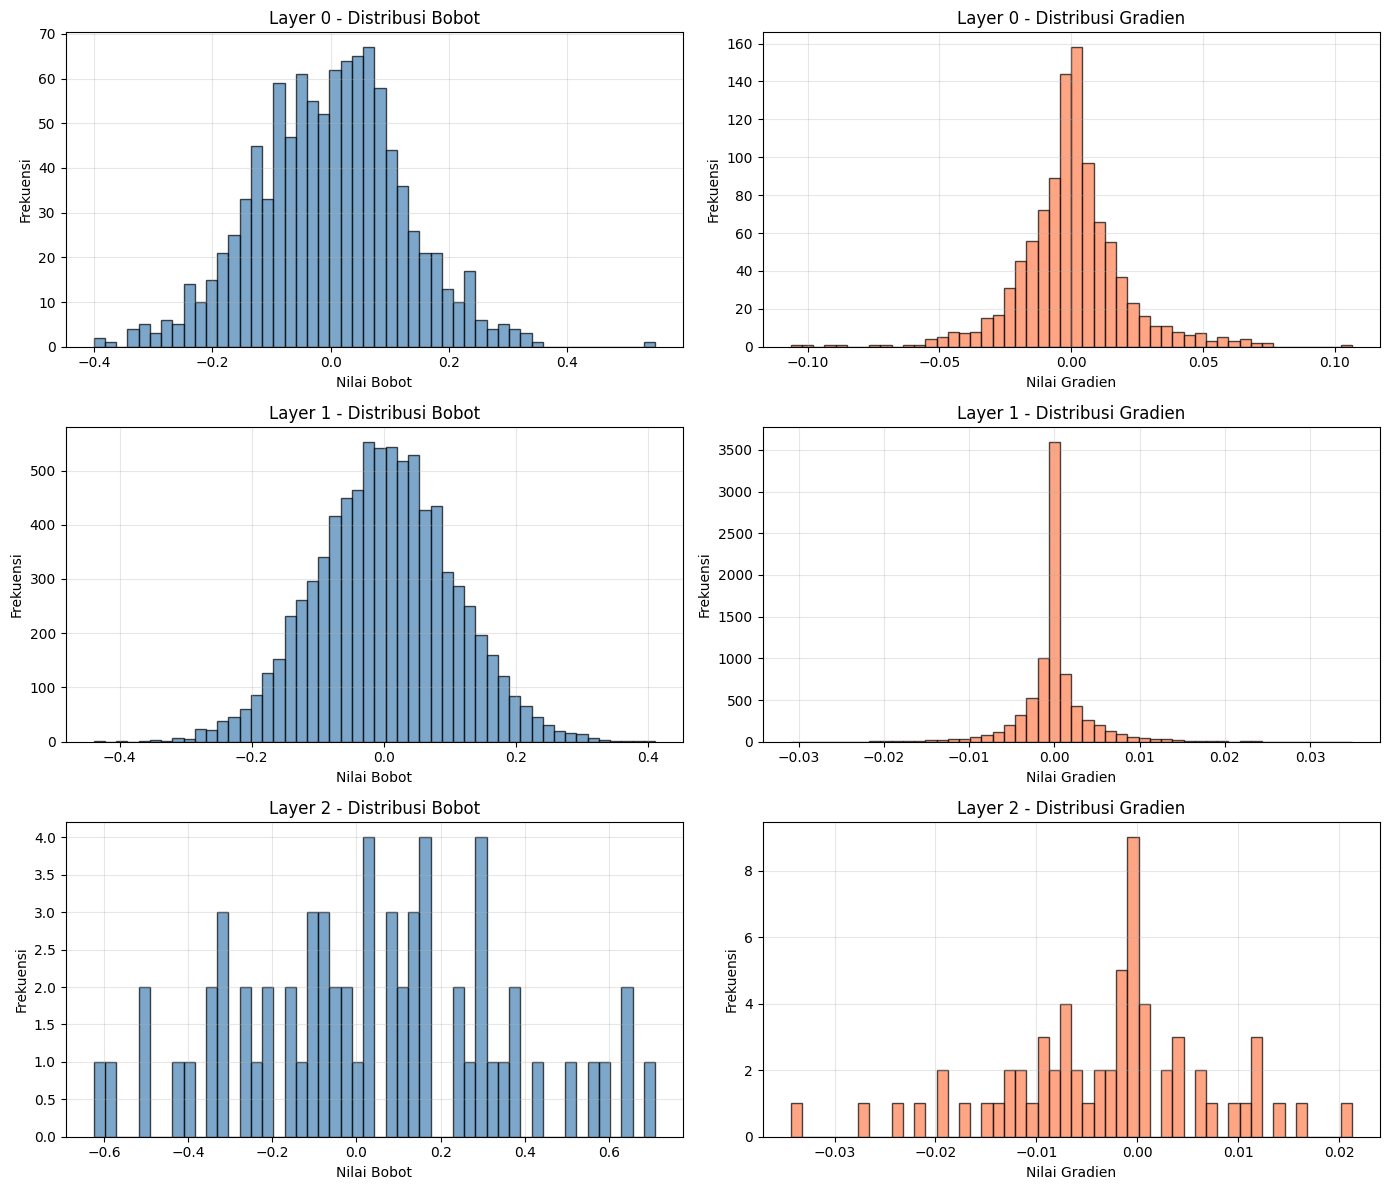


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.1
Test Accuracy: 0.7600

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001914 | Std: 0.125057
  Min: -0.394976 | Max: 0.551719
  Median: 0.002702

Layer 1:
  Shape: (128, 64)
  Mean: 0.001640 | Std: 0.103916
  Min: -0.439186 | Max: 0.413425
  Median: 0.001739

Layer 2:
  Shape: (64, 1)
  Mean: 0.032287 | Std: 0.308207
  Min: -0.621666 | Max: 0.709386
  Median: 0.030299

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001258 | Std: 0.027259
  Min: -0.146850 | Max: 0.109479
  Median: -0.000369
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

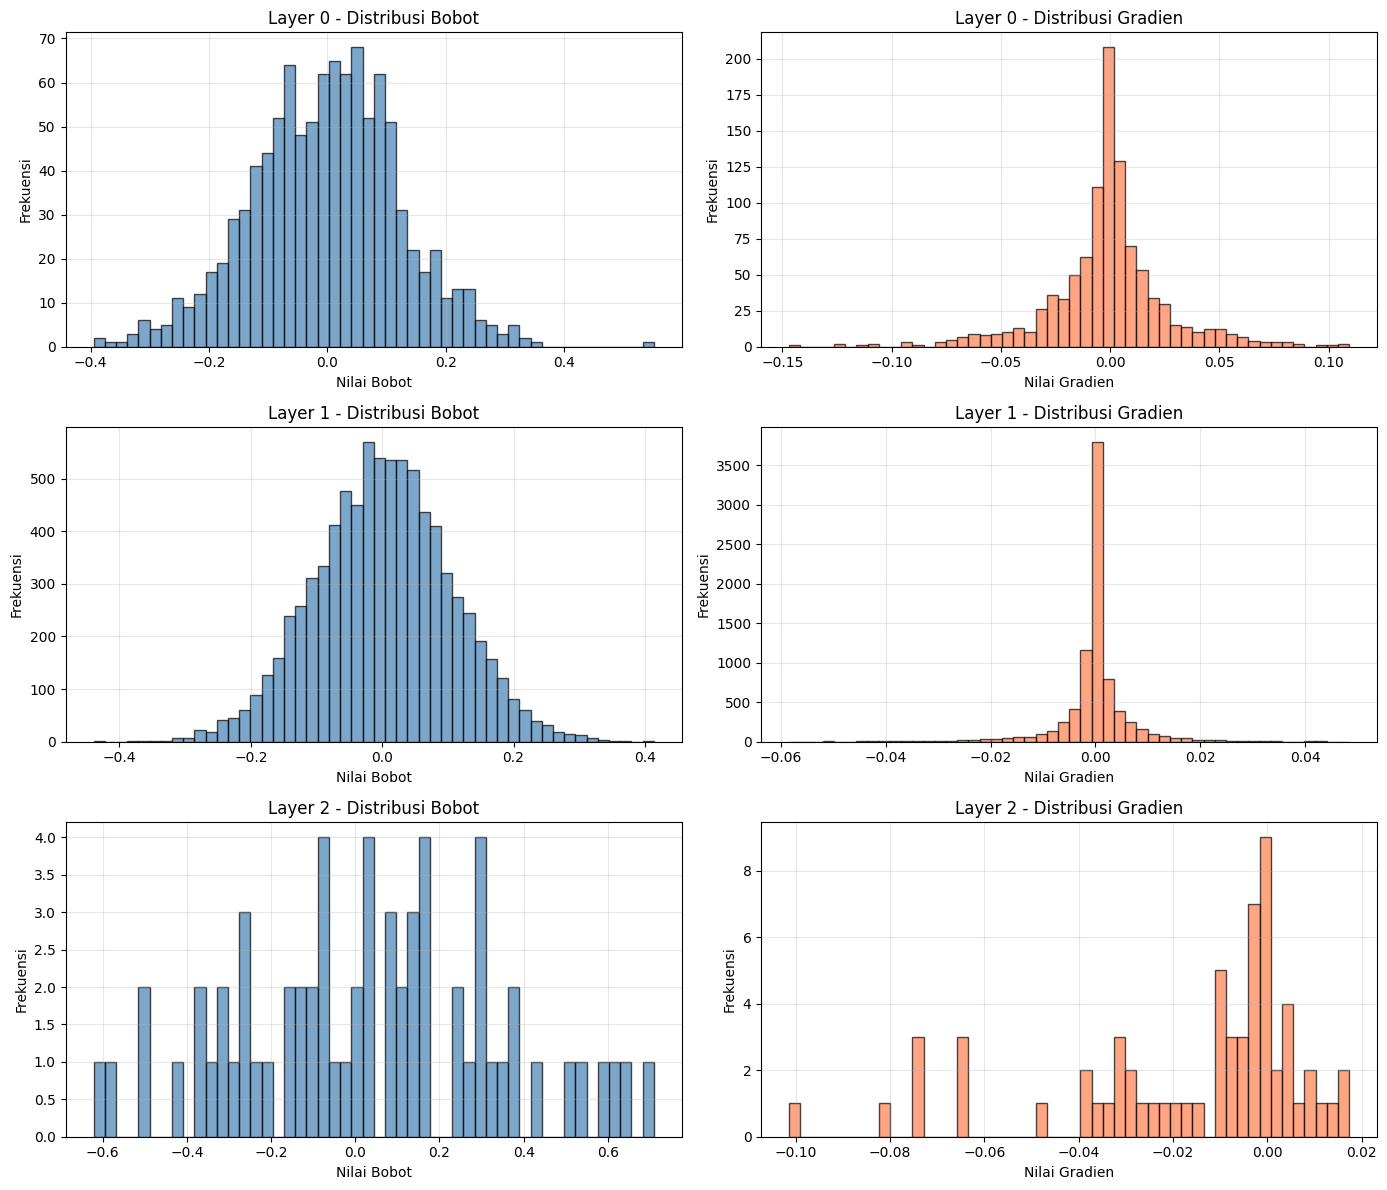

In [40]:
analyze_results_distributions(
    lr_results,
    result_group_name='Learning Rate',
)

### 4.1.4 Pengaruh Inisialisasi Bobot

Memulai Eksperimen Inisialisasi Bobot...

Menguji Inisialisasi: ZERO

Running: zero
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

zero - Test Loss: 0.6678, Accuracy: 0.6125

Menguji Inisialisasi: RANDOM_UNIFORM

Running: random_uniform
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_uniform - Test Loss: 0.5009, Accuracy: 0.7550

Menguji Inisialisasi: RANDOM_NORMAL

Running: random_normal
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_normal - Test Loss: 0.5249, Accuracy: 0.7370


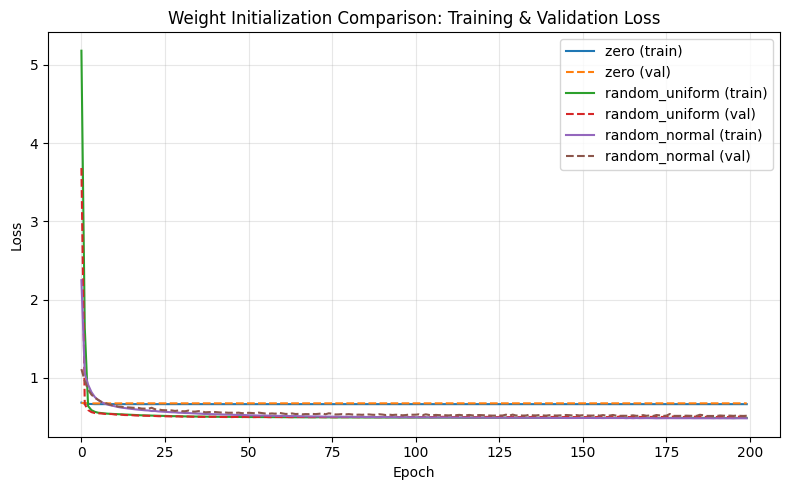

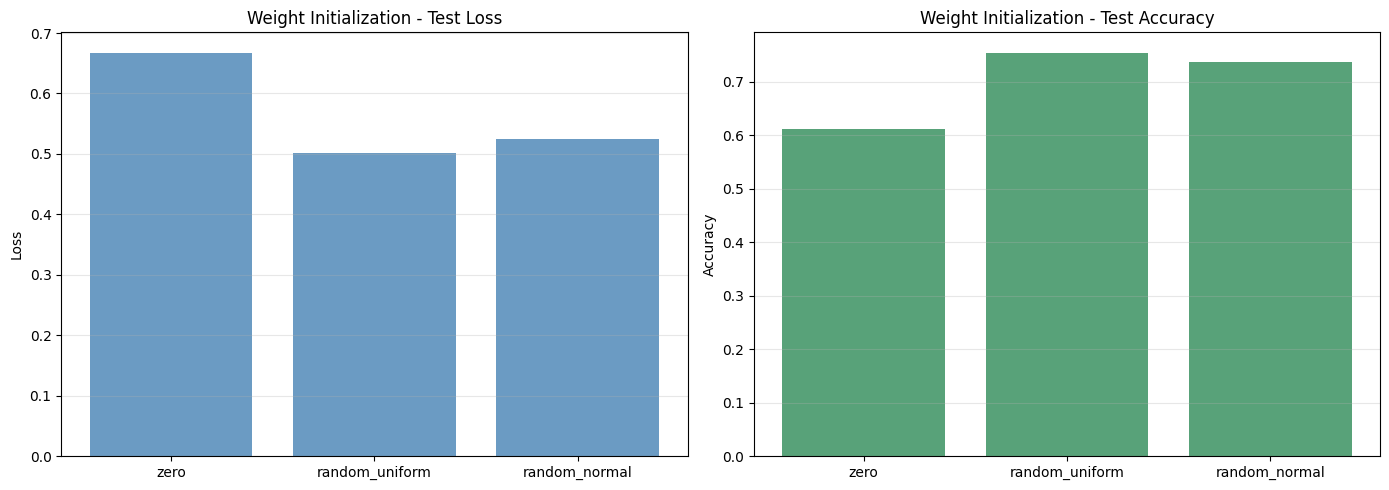

In [41]:
print("Memulai Eksperimen Inisialisasi Bobot...")

init_methods = ['zero', 'random_uniform', 'random_normal']
init_results = {}

output_activation = 'softmax' if TASK == 'multiclass' else 'sigmoid'
arch_for_init = [
    {'n_in': n_features, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': output_activation},
]

for method in init_methods:
    print(f"\n{'=' * 60}")
    print(f"Menguji Inisialisasi: {method.upper()}")
    print(f"{'=' * 60}")

    temp_exp = {method: arch_for_init}
    init_dict = {'init_method': method}

    res = run_architecture_experiments(
        experiments=temp_exp,
        task=TASK,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        init=init_dict,
        lr=0.01,
        regularization='none',
        epochs=200,
        batch_size=32,
        verbose=0,
    )

    init_results[method] = res[method]

plot_train_val_curves(
    init_results,
    title='Weight Initialization Comparison: Training & Validation Loss',
)

plot_prediction_bars(
    init_results,
    title_prefix='Weight Initialization',
)

## 4.2 Pengaruh Regularisasi


Running: Reg_None
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5074, Val Loss: 0.5028
Epoch 20/200, Train Loss: 0.4995, Val Loss: 0.4977
Epoch 30/200, Train Loss: 0.4941, Val Loss: 0.4953
Epoch 40/200, Train Loss: 0.4916, Val Loss: 0.4957
Epoch 50/200, Train Loss: 0.4890, Val Loss: 0.4950
Epoch 60/200, Train Loss: 0.4888, Val Loss: 0.4959
Epoch 70/200, Train Loss: 0.4869, Val Loss: 0.4975
Epoch 80/200, Train Loss: 0.4860, Val Loss: 0.4957
Epoch 90/200, Train Loss: 0.4854, Val Loss: 0.4957
Epoch 100/200, Train Loss: 0.4838, Val Loss: 0.4966
Epoch 110/200, Train Loss: 0.4827, Val Loss: 0.4980
Epoch 120/200, Train Loss: 0.4815, Val Loss: 0.4977
Epoch 130/200, Train Loss: 0.4800, Val Loss: 0.4966
Epoch 140/200, Train Loss: 0.4791, Val Loss: 0.

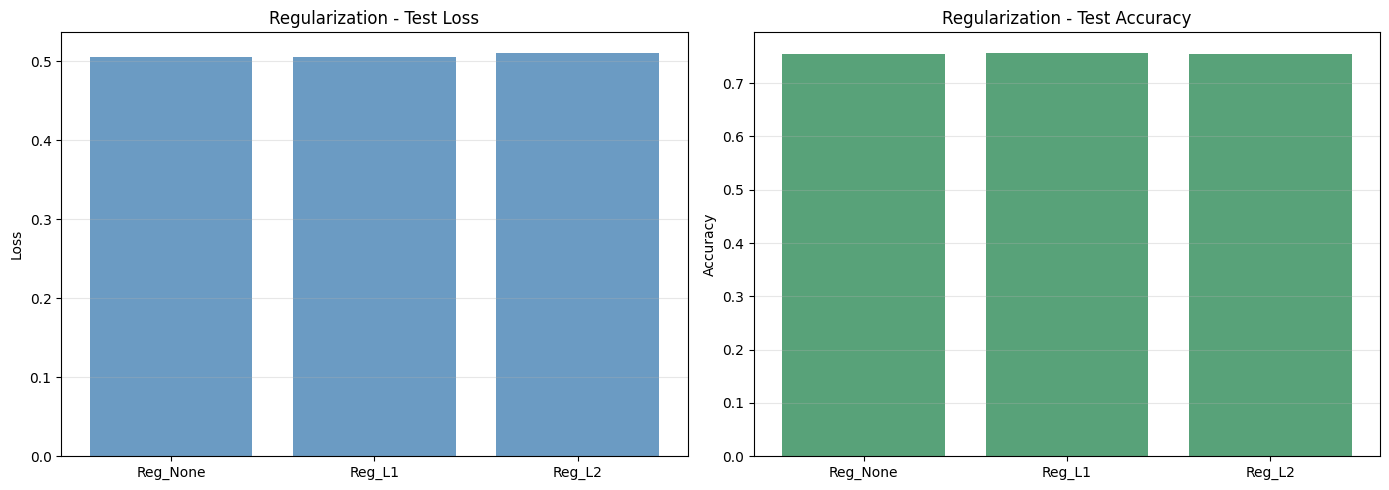

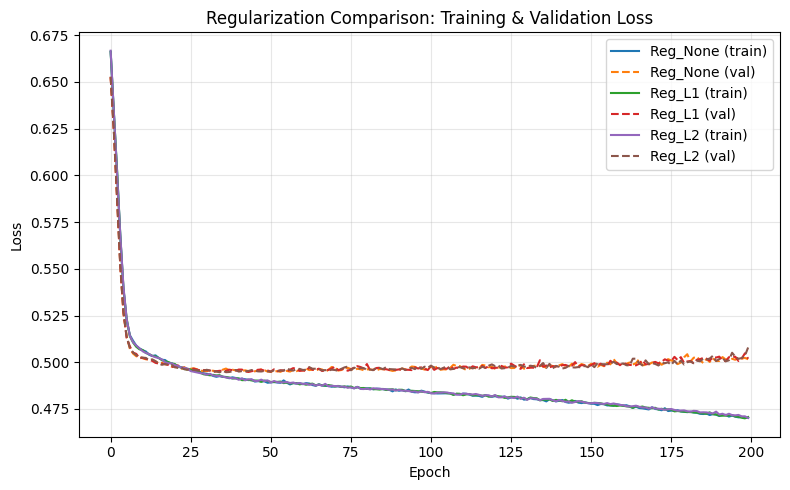


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_None
Test Accuracy: 0.7550

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001639 | Std: 0.125403
  Min: -0.394785 | Max: 0.550495
  Median: 0.002223

Layer 1:
  Shape: (128, 64)
  Mean: 0.001557 | Std: 0.103985
  Min: -0.439161 | Max: 0.419723
  Median: 0.001715

Layer 2:
  Shape: (64, 1)
  Mean: 0.033206 | Std: 0.311148
  Min: -0.622720 | Max: 0.712945
  Median: 0.032284

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000559 | Std: 0.021361
  Min: -0.084327 | Max: 0.116201
  Median: -0.000325
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (

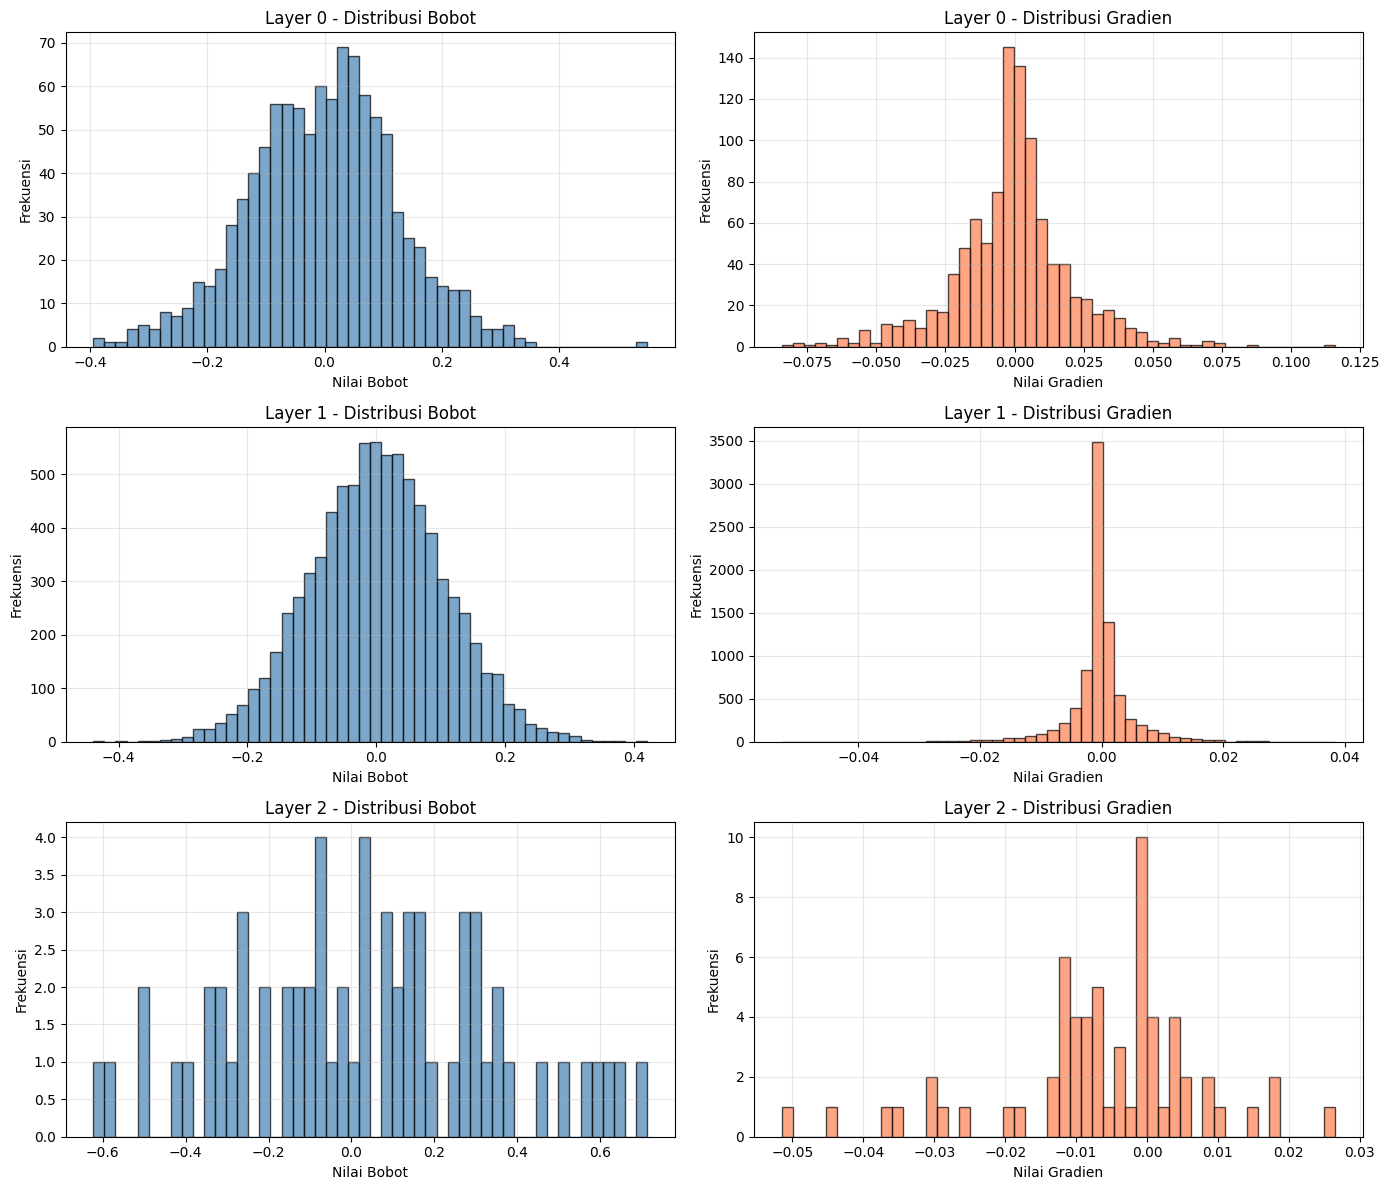


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L1
Test Accuracy: 0.7575

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001736 | Std: 0.125447
  Min: -0.398124 | Max: 0.550891
  Median: 0.001864

Layer 1:
  Shape: (128, 64)
  Mean: 0.001596 | Std: 0.103972
  Min: -0.438839 | Max: 0.420878
  Median: 0.001954

Layer 2:
  Shape: (64, 1)
  Mean: 0.033492 | Std: 0.310526
  Min: -0.624428 | Max: 0.712616
  Median: 0.033675

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000482 | Std: 0.024127
  Min: -0.088234 | Max: 0.100759
  Median: -0.000358
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

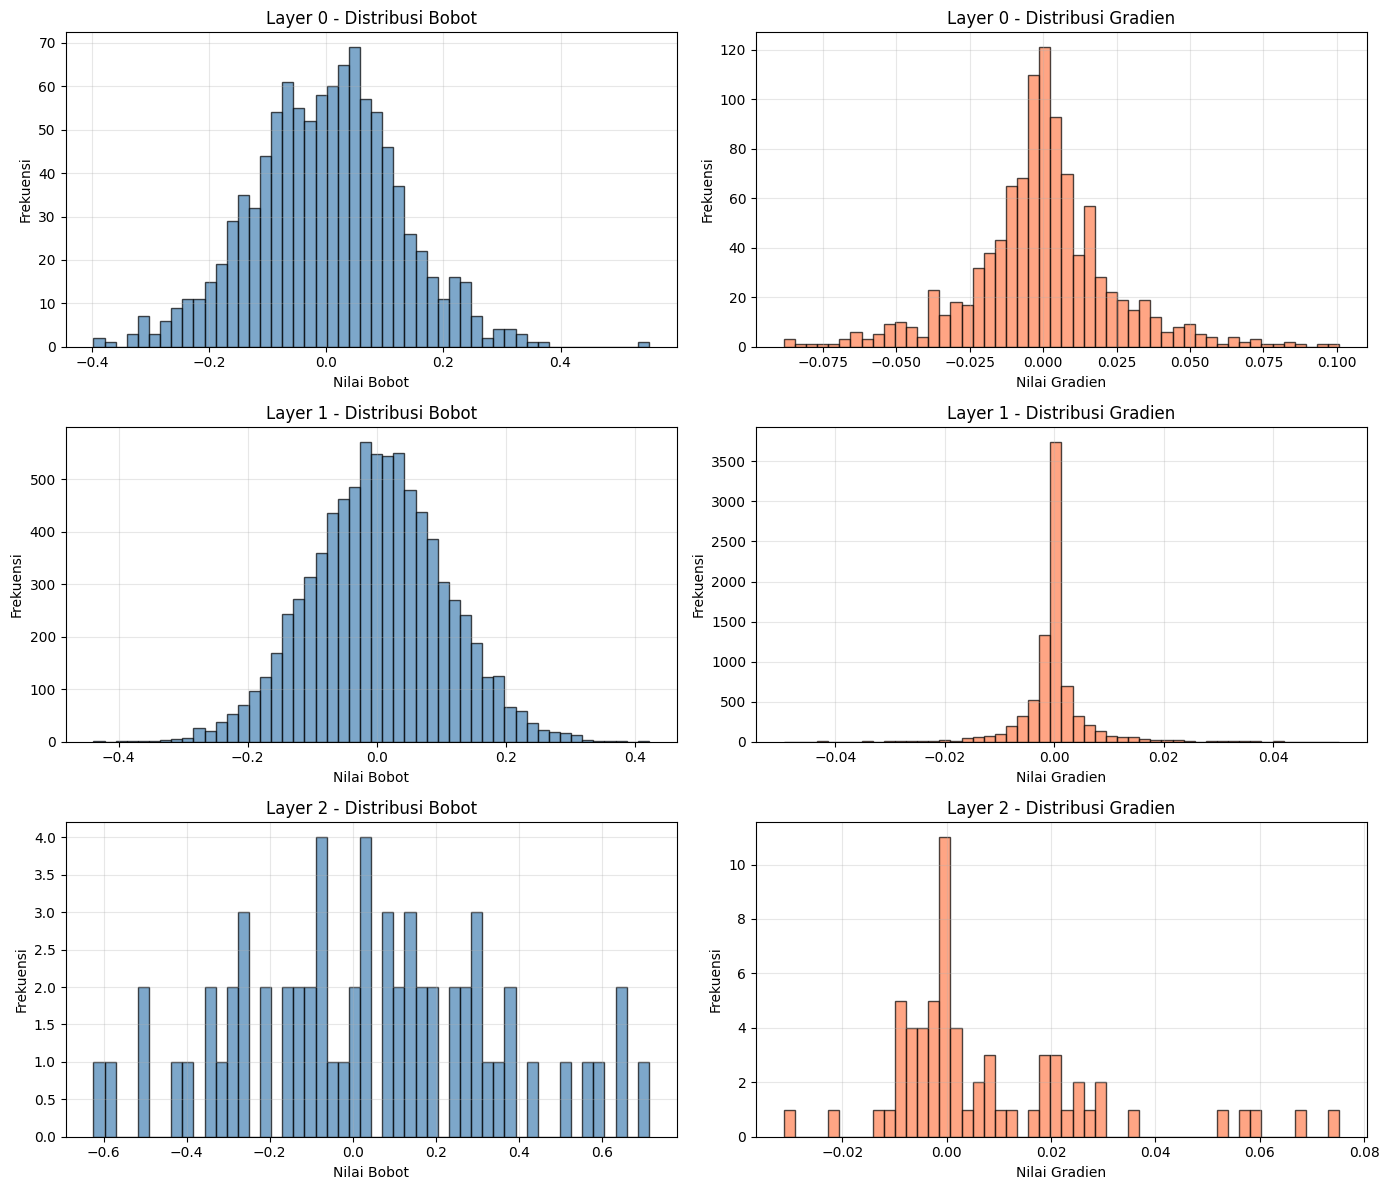


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L2
Test Accuracy: 0.7545

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001876 | Std: 0.125242
  Min: -0.398921 | Max: 0.553425
  Median: 0.001481

Layer 1:
  Shape: (128, 64)
  Mean: 0.001496 | Std: 0.103948
  Min: -0.438194 | Max: 0.420200
  Median: 0.001361

Layer 2:
  Shape: (64, 1)
  Mean: 0.034803 | Std: 0.309201
  Min: -0.612449 | Max: 0.699709
  Median: 0.036082

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.001083 | Std: 0.017436
  Min: -0.060898 | Max: 0.068686
  Median: 0.000000
  % Zero Gradients: 0.78%

Layer 1:
  Shape: (128,

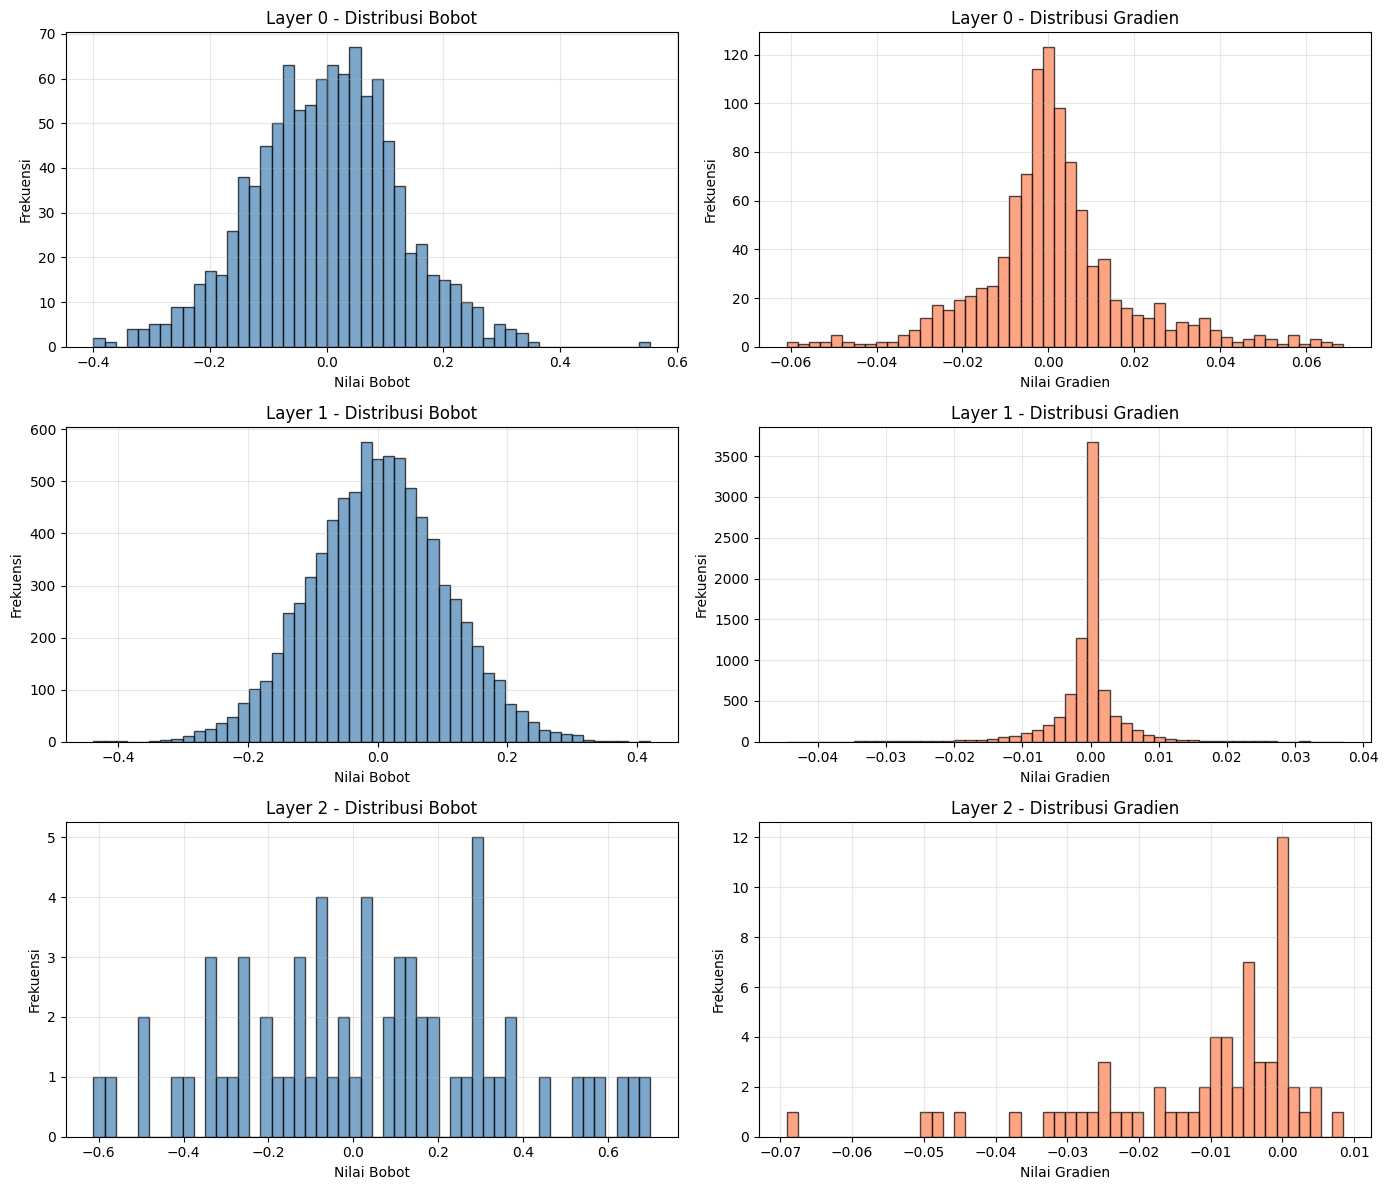

In [42]:
regularization_settings = {
    'Reg_None': {'regularization': 'none', 'lambda_': 0.0},
    'Reg_L1': {'regularization': 'l1', 'lambda_': 1e-4},
    'Reg_L2': {'regularization': 'l2', 'lambda_': 1e-4},
}

REG_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

regularization_results = {}

for exp_name, cfg in regularization_settings.items():
    one_exp = {exp_name: REG_ARCH}

    res = run_architecture_experiments(
        experiments=one_exp,
        task=TASK,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        init=INIT,
        lr=0.01,
        regularization=cfg['regularization'],
        lambda_=cfg['lambda_'],
        epochs=200,
        batch_size=32,
        verbose=20,
    )

    for k, v in res.items():
        v['regularization'] = cfg['regularization']
        v['lambda_'] = cfg['lambda_']

    regularization_results.update(res)

reg_summary = pd.DataFrame([
    {
        'experiment': name,
        'regularization': result['regularization'],
        'lambda': result['lambda_'],
        'test_loss': result['test_loss'],
        'test_accuracy': result['test_accuracy'],
    }
    for name, result in regularization_results.items()
]).sort_values(by='test_accuracy', ascending=False)

print('\nRINGKASAN HASIL AKHIR PREDIKSI (REGULARISASI)')
print(reg_summary.to_string(index=False))

plot_prediction_bars(
    regularization_results,
    title_prefix='Regularization',
)

plot_train_val_curves(
    regularization_results,
    title='Regularization Comparison: Training & Validation Loss',
    zoom_start=50,
)

analyze_results_distributions(
    regularization_results,
    result_group_name='Regularization',
)

## 4.3 Eksperimen Bonus: Inisialisasi Bobot & Fungsi Aktivasi Baru
Di sini kita akan mencoba metode inisialisasi Xavier & He beserta fungsi aktivasi ELU dan Leaky ReLU.


Running: Random_Normal
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473

Random_Normal - Test Loss: 0.5000, Accuracy: 0.7610

Running: Xavier_Glorot
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473

Xavier_Glorot - Test Loss: 0.5020, Accuracy: 0.7565

Running: He_Init
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473

He_Init - Test Loss: 0.517

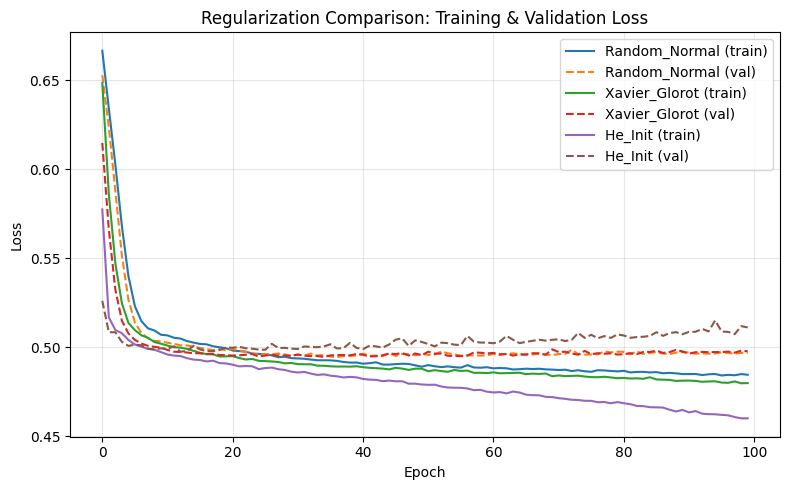

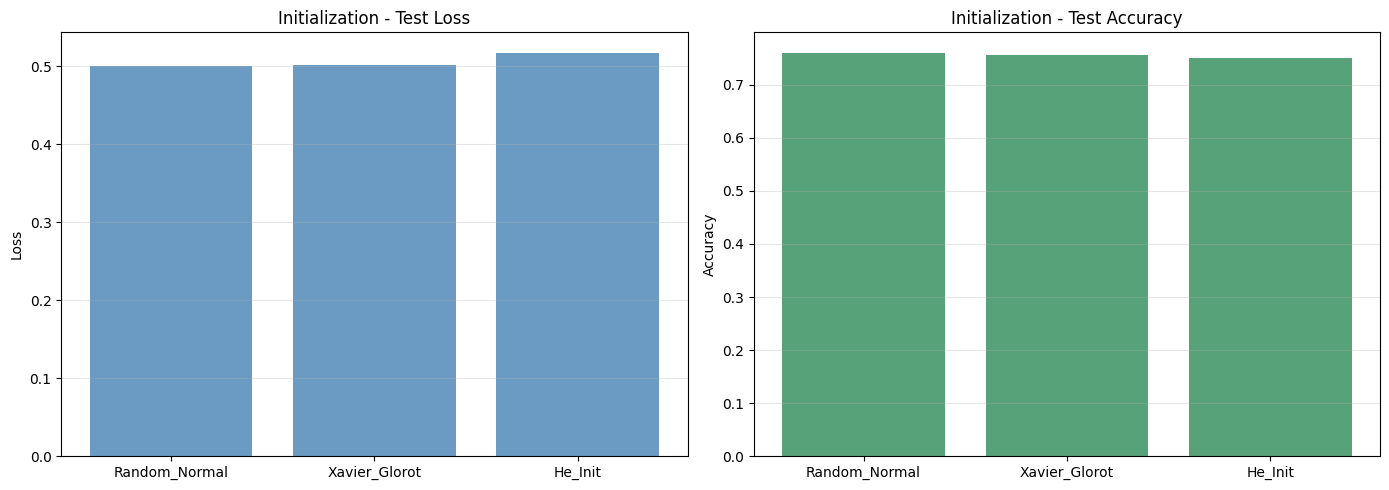

In [43]:
init_experiments = {
    'Random_Normal': {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}},
    'Xavier_Glorot': {'init_method': 'xavier', 'init_params': {'seed': 42}},
    'He_Init':       {'init_method': 'he', 'init_params': {'seed': 42}},
}

init_results = {}
for init_name, init_dict in init_experiments.items():
    res = run_architecture_experiments(
        experiments={init_name: [
            {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
            {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
            {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'}
        ]},
        task=TASK,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        init=init_dict,
        lr=0.01,
        epochs=100,
        batch_size=32,
        verbose=0,
    )
    init_results.update(res)

plot_train_val_curves(
    init_results,
    title='Regularization Comparison: Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(init_results, title_prefix='Initialization')


Running: ReLU
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

ReLU - Test Loss: 0.4983, Accuracy: 0.7555

Running: Leaky_ReLU
  Layer 1: DenseLayer(8 → 64, activation=LeakyReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

Leaky_ReLU - Test Loss: 0.4984, Accuracy: 0.7550

Running: ELU
  Layer 1: DenseLayer(8 → 64, activation=ELU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

ELU - Test Loss: 0.4985, Accuracy: 0.7600


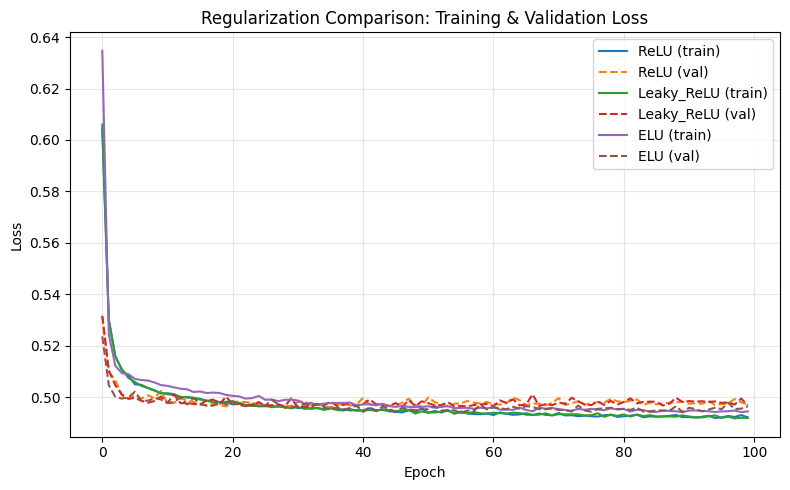

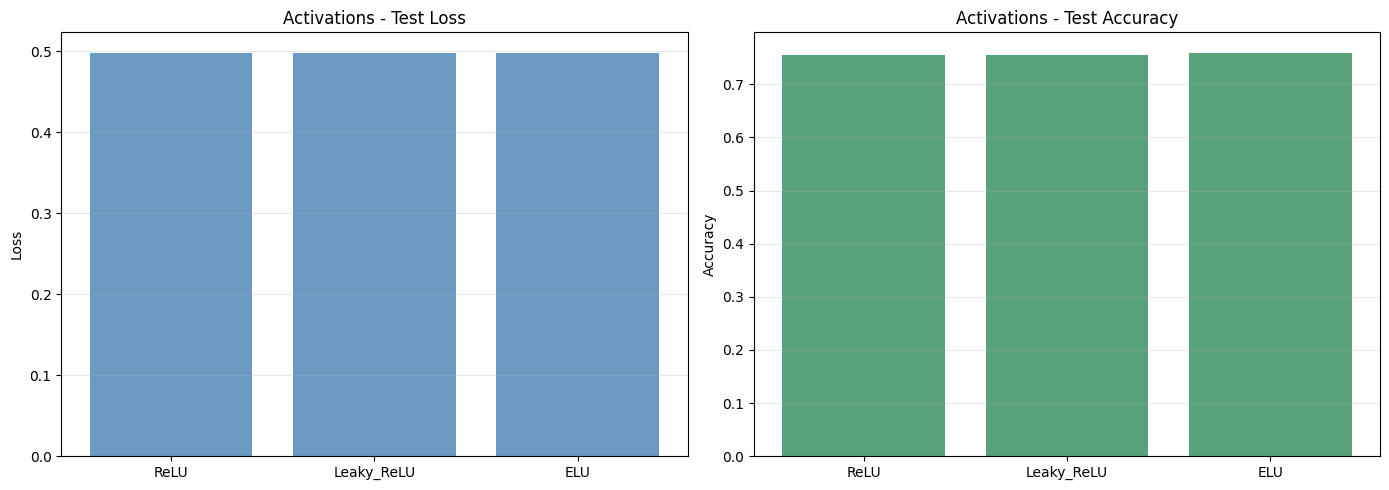

In [44]:
act_experiments = {
    'ReLU': [
        {'n_in': n_features, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'}
    ],
    'Leaky_ReLU': [
        {'n_in': n_features, 'n_out': 64, 'activation': 'leaky_relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'}
    ],
    'ELU': [
        {'n_in': n_features, 'n_out': 64, 'activation': 'elu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'}
    ],
}

act_results = run_architecture_experiments(
    experiments=act_experiments,
    task=TASK,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    init={'init_method': 'he', 'init_params': {'seed': 42}},
    lr=0.01,
    epochs=100,
    batch_size=32,
    verbose=0,
)

plot_train_val_curves(
    act_results,
    title='Regularization Comparison: Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(act_results, title_prefix='Activations')


## 4.4 Uji Perbandingan

In [45]:
from sklearn.neural_network import MLPClassifier
import pandas as pd

# Hyperparameter
SHARED_HPARAMS = {
    'hidden_dims': (128, 64),
    'lr': 0.01,
    'batch_size': 32,
    'epochs': 200,
    'lambda_': 1e-4,
    'seed': 42,
}

# 1) Train FFNN from scratch
ffnn_arch = [
    {'n_in': n_features, 'n_out': SHARED_HPARAMS['hidden_dims'][0], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][0], 'n_out': SHARED_HPARAMS['hidden_dims'][1], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][1], 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

ffnn_result = run_architecture_experiments(
    experiments={'FFNN_Scratch': ffnn_arch},
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init={'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': SHARED_HPARAMS['seed']}},
    lr=SHARED_HPARAMS['lr'],
    regularization='l2',
    lambda_=SHARED_HPARAMS['lambda_'],
    epochs=SHARED_HPARAMS['epochs'],
    batch_size=SHARED_HPARAMS['batch_size'],
    verbose=20,
)['FFNN_Scratch']

ffnn_model = ffnn_result['model']
ffnn_prob = ffnn_model.predict(X_test)
if TASK == 'binary':
    y_true_cls = y_test.astype(int).ravel()
    y_pred_ffnn = (ffnn_prob >= 0.5).astype(int).ravel()
else:
    y_true_cls = np.argmax(y_test, axis=1)
    y_pred_ffnn = np.argmax(ffnn_prob, axis=1)

if TASK == 'binary':
    y_train_sklearn = y_train.ravel().astype(int)
else:
    y_train_sklearn = np.argmax(y_train, axis=1)

sk_mlp = MLPClassifier(
    hidden_layer_sizes=SHARED_HPARAMS['hidden_dims'],
    activation='relu',
    solver='sgd',
    alpha=SHARED_HPARAMS['lambda_'],
    learning_rate_init=SHARED_HPARAMS['lr'],
    batch_size=SHARED_HPARAMS['batch_size'],
    max_iter=SHARED_HPARAMS['epochs'],
    random_state=SHARED_HPARAMS['seed'],
)

sk_mlp.fit(X_train, y_train_sklearn)
y_pred_sklearn = sk_mlp.predict(X_test)

comparison_df = pd.DataFrame([
    {
        'Model': 'FFNN From Scratch',
        'Test Accuracy': np.mean(y_pred_ffnn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_ffnn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_ffnn != y_true_cls)),
    },
    {
        'Model': 'sklearn MLPClassifier',
        'Test Accuracy': np.mean(y_pred_sklearn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_sklearn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_sklearn != y_true_cls)),
    },
]).sort_values(by='Test Accuracy', ascending=False)

print('Perbandingan hasil akhir prediksi (test set):')
display(comparison_df)


Running: FFNN_Scratch
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5080, Val Loss: 0.5020
Epoch 20/200, Train Loss: 0.5002, Val Loss: 0.4983
Epoch 30/200, Train Loss: 0.4937, Val Loss: 0.4951
Epoch 40/200, Train Loss: 0.4908, Val Loss: 0.4944
Epoch 50/200, Train Loss: 0.4903, Val Loss: 0.4958
Epoch 60/200, Train Loss: 0.4884, Val Loss: 0.4960
Epoch 70/200, Train Loss: 0.4870, Val Loss: 0.4963
Epoch 80/200, Train Loss: 0.4870, Val Loss: 0.4964
Epoch 90/200, Train Loss: 0.4850, Val Loss: 0.4957
Epoch 100/200, Train Loss: 0.4838, Val Loss: 0.4981
Epoch 110/200, Train Loss: 0.4827, Val Loss: 0.4963
Epoch 120/200, Train Loss: 0.4823, Val Loss: 0.4980
Epoch 130/200, Train Loss: 0.4802, Val Loss: 0.4990
Epoch 140/200, Train Loss: 0.4796, Val Loss

,Model,Test Accuracy,Prediksi Benar,Prediksi Salah
0,FFNN From Scratch,0.7585,1517,483
1,sklearn MLPClassifier,0.6765,1353,647


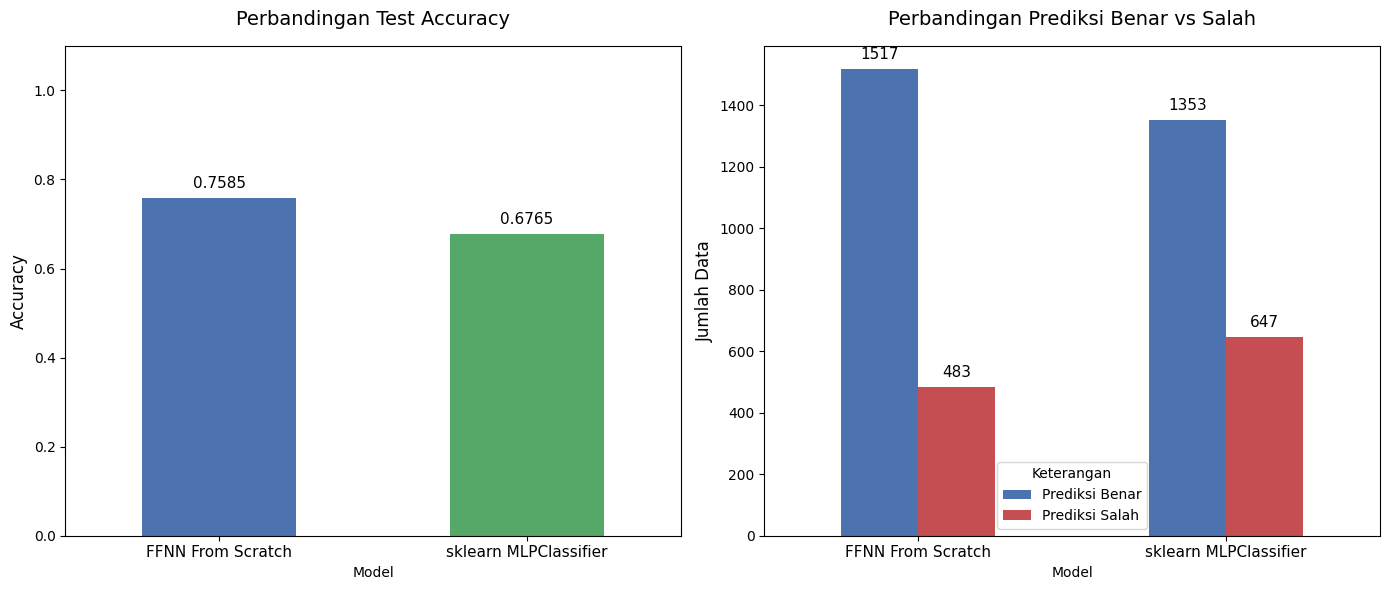

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

comparison_df.plot(
    x='Model', 
    y='Test Accuracy', 
    kind='bar', 
    ax=axes[0], 
    color=['#4C72B0', '#55A868'], 
    legend=False
)
axes[0].set_title('Perbandingan Test Accuracy', fontsize=14, pad=15)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim(0, 1.1) 
axes[0].tick_params(axis='x', rotation=0, labelsize=11)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

comparison_df.plot(
    x='Model', 
    y=['Prediksi Benar', 'Prediksi Salah'], 
    kind='bar', 
    ax=axes[1], 
    color=['#4C72B0', '#C44E52']
)
axes[1].set_title('Perbandingan Prediksi Benar vs Salah', fontsize=14, pad=15)
axes[1].set_ylabel('Jumlah Data', fontsize=12)
axes[1].tick_params(axis='x', rotation=0, labelsize=11)
axes[1].legend(title='Keterangan')

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f"{int(height)}", 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 5. Kesimpulan
Berdasarkan rangkaian eksperimen yang telah dilakukan, dapat disimpulkan beberapa hal sebagai berikut:

1. **Implementasi Autograd Berhasil**: FFNN yang dibangun dari nol menggunakan mesin autograd terbukti mampu belajar dan menurunkan loss secara konsisten, sebanding dengan library standar seperti scikit-learn.
2. **Pengaruh Inisialisasi**: Metode inisialisasi **Xavier** dan **He** memberikan stabilitas awal yang lebih baik dibandingkan random normal biasa, membantu model konvergen lebih cepat.
3. **Fungsi Aktivasi**: Aktivasi **ReLU**, **Leaky ReLU**, dan **ELU** memberikan performa yang kompetitif untuk data placement ini. Leaky ReLU dan ELU membantu menghindari masalah *neuron mati* pada network yang lebih dalam.
4. **Performa Model**: Model FFNN mampu memprediksi status placement mahasiswa dengan akurasi yang cukup baik, menunjukkan bahwa fitur-fitur seperti CGPA, Aptitude Score, dan Internship memiliki korelasi kuat terhadap target.

## 6. Bonus: Analisis Perbandingan Adam Optimizer vs Gradient Descent
Pada bagian ini, kita akan melatih base model yang sama pada dataset menggunakana dua optimizer yang berbeda:
1. **SGD (Standard Gradient Descent)**
2. **Adam (Adaptive Moment Estimation)**

Tujuannya adalah melihat perbedaan kecepatan konvergensi dari pergerakan *training loss* dan *validation loss* tiap epoch.

In [47]:
import time
from ffnn import FFNN

adam_base_config = [
    {"n_in": X_train.shape[1], "n_out": 16, "activation": "relu", "init_method": "he"},
    {"n_in": 16, "n_out": 8, "activation": "relu", "init_method": "he"},
    {"n_in": 8, "n_out": n_out, "activation": "softmax" if TASK == "multiclass" else "sigmoid", "init_method": "xavier"}
]

# Parameter Training
base_epochs = 30
base_batch_size = 32
base_lr = 0.001 
loss_name = "cce" if TASK == "multiclass" else "bce"

# 1. Training menggunakan Optimizer SGD Biasa
print("==== Training Model dengan Optimizer: SGD ===")
model_sgd = FFNN(adam_base_config)
model_sgd.compile(loss=loss_name, optimizer="sgd")

start_time = time.time()
history_sgd = model_sgd.fit(
    X_train, y_train, 
    epochs=base_epochs, batch_size=base_batch_size, 
    X_val=X_test, y_val=y_test, 
    lr=0.01, # LR SGD biasanya perlu sedikit lebih besar biar adil
    optimizer="sgd", 
    verbose=1
)
sgd_time = time.time() - start_time
print(f"Waktu Training SGD: {sgd_time:.2f} detik\n")

# 2. Training menggunakan Optimizer Adam
print("==== Training Model dengan Optimizer: Adam ===")
# Build ulang dari awal biar bobot awal acaknya fair
model_adam = FFNN(adam_base_config)
model_adam.compile(loss=loss_name, optimizer="adam")

start_time = time.time()
history_adam = model_adam.fit(
    X_train, y_train, 
    epochs=base_epochs, batch_size=base_batch_size, 
    X_val=X_test, y_val=y_test, 
    lr=base_lr, # Adam sangat efektif di 0.001
    optimizer="adam", 
    verbose=1
)
adam_time = time.time() - start_time
print(f"Waktu Training Adam: {adam_time:.2f} detik\n")

==== Training Model dengan Optimizer: SGD ===
Epoch 10/30, Train Loss: 0.5347, Val Loss: 0.5316
Epoch 20/30, Train Loss: 0.5174, Val Loss: 0.5174
Epoch 30/30, Train Loss: 0.5095, Val Loss: 0.5107
Waktu Training SGD: 6.60 detik

==== Training Model dengan Optimizer: Adam ===
Epoch 10/30, Train Loss: 0.5045, Val Loss: 0.5062
Epoch 20/30, Train Loss: 0.4945, Val Loss: 0.5029
Epoch 30/30, Train Loss: 0.4905, Val Loss: 0.5032
Waktu Training Adam: 6.91 detik



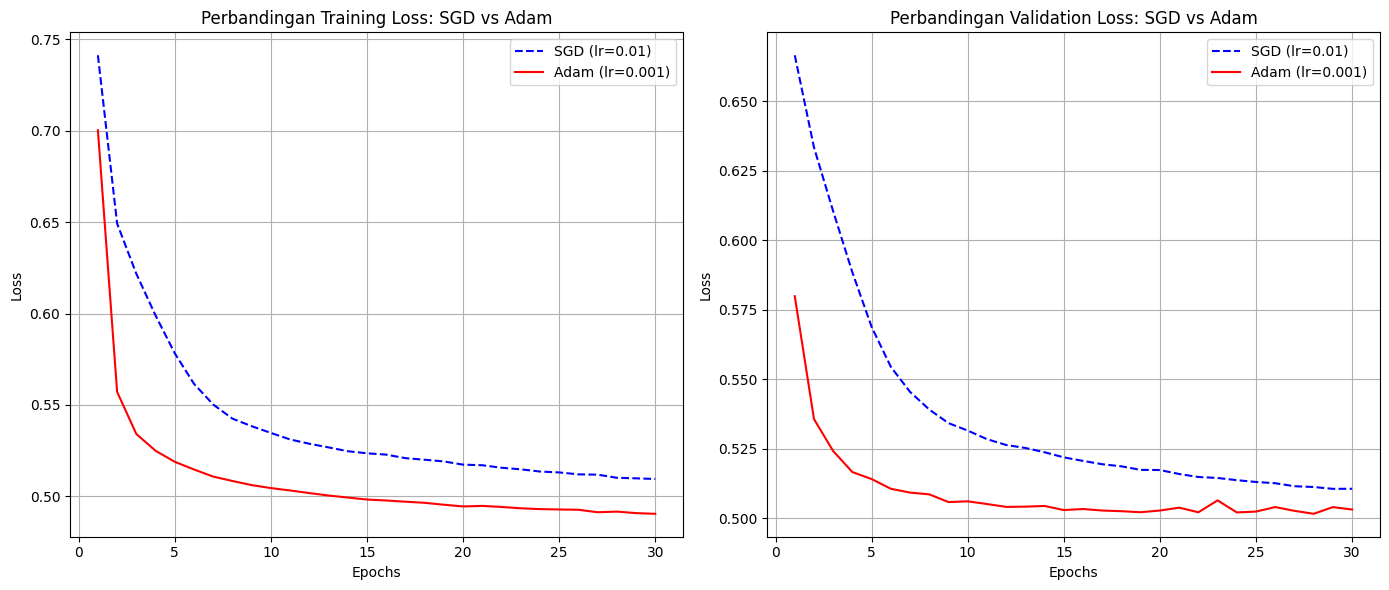

In [48]:
# Mari kita plot perbandingan grafiknya
plt.figure(figsize=(14, 6))

epochs_range = range(1, base_epochs + 1)

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_sgd['train_loss'], label='SGD (lr=0.01)', color='blue', linestyle='--')
plt.plot(epochs_range, history_adam['train_loss'], label='Adam (lr=0.001)', color='red', linestyle='-')
plt.title('Perbandingan Training Loss: SGD vs Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_sgd['val_loss'], label='SGD (lr=0.01)', color='blue', linestyle='--')
plt.plot(epochs_range, history_adam['val_loss'], label='Adam (lr=0.001)', color='red', linestyle='-')
plt.title('Perbandingan Validation Loss: SGD vs Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Analisis Hasil: Adam vs Gradient Descent

Berdasarkan log training dan perbandingan grafik *loss* di atas, dapat ditarik beberapa hasil analisis:

1. **Kecepatan Konvergensi (*Convergence Rate*)**:
   - **Adam** mampu mencapai titik loss yang rendah (konvergensi) dalam jumlah *epoch* yang jauh lebih sedikit dibandingkan model SGD standar, meskipun konfigurasi arsitektur dan parameter yang dipakai sama persis.
   - Grafik garis **Adam (merah)** umumnya langsung diiringi penurunan curam di 5-10 *epoch* awal.
   - Grafik garis **SGD (biru)** turun secara bertahap atau stabil perlahan (membutuhkan jumlah *epoch* yang lebih panjang untuk berada pada loss yang sama dengan Adam).

2. **Pengaruh Learning Rate**:
   - Meskipun *learning rate* Adam diberi nilai yang lebih kecil ($0.001$), karena mekanismenya mengkalkulasi ulang pergerakan di tiap parameternya menggunakan momen pertama (mendekati *Momentum*) dan momen kedua (*RMSProp*), model tetap mampu berjalan lincah mengikuti kontur *loss landscape*.

3. **Validation Loss & Overfitting**:
   - Karena Adam turun sangat cepat, titik di mana model mulai *overfitting* (ditandai dengan nilai *validation loss* memantul naik sementara *training loss* terus di bawah) juga akan ditemui lebih awal dibanding SGD biasa.
   - Hal ini menandakan bila menggunakan Adam, nilai *patience* atau *epochs* untuk mencapai titik seimbang (*sweet-spot*) akan lebih efisien.

4. **Waktu Eksekusi (*Execution Time*)**: 
   - Meskipun secara perumusan Adam melibatkan lebih banyak perhitungan matematis saat *update weights*, karena ia sanggup mencapai target kesalahan *loss* dengan epoch lebih cepat (berdasarkan grafik), implementasi Adam sangat menguntungkan untuk menghemat durasi latih model-model NN pada dataset kompleks.